### 1- Table EVENTS


#### Variables de la table `events` — Dictionnaire complet

##### Temporelles
| Variable | Type | Description |
|---|---|---|
| `SQLDATE` | int64 | Date de l'événement (YYYYMMDD) |
| `DATEADDED` | int64 | Date d'ajout dans GDELT (YYYYMMDDHHmmSS) — peut différer de SQLDATE |

---

##### Structure de l'événement
| Variable | Type | Description |
|---|---|---|
| `IsRootEvent` | int64 | 1 = événement racine (article original), 0 = événement dérivé (reprise) |
| `EventCode` | int64 | Code CAMEO précis de l'action (ex: 190 = usage de la force) |
| `EventBaseCode` | int64 | Version simplifiée de EventCode (2 chiffres) |
| `EventRootCode` | int64 | Version racine de EventCode (1-2 chiffres) — 20 catégories max |
| `QuadClass` | int64 | Catégorie large : 1=Déclaration, 2=Coopération, 3=Conflit verbal, 4=Conflit matériel |

---

##### Acteur 1 — L'initiateur de l'action
| Variable | Type | Description |
|---|---|---|
| `Actor1Name` | object | Nom textuel de l'acteur 1 (ex: "GOVERNMENT", "POLICE") |
| `Actor1CountryCode` | object | Code CAMEO du pays de l'acteur 1 (ex: BEN = Bénin) |
| `Actor1Type1Code` | object | Type de l'acteur 1 (ex: GOV=gouvernement, MIL=militaire, LEG=législatif) |

---

##### Acteur 2 — La cible ou le second acteur
| Variable | Type | Description |
|---|---|---|
| `Actor2Name` | object | Nom textuel de l'acteur 2 |
| `Actor2CountryCode` | object | Code CAMEO du pays de l'acteur 2 |
| `Actor2Type1Code` | object | Type de l'acteur 2 |

---

##### Scores analytiques
| Variable | Type | Interprétation |
|---|---|---|
| `GoldsteinScale` | float64 | Impact théorique sur la stabilité nationale. [-10 = très déstabilisateur, +10 = très stabilisateur] |
| `AvgTone` | float64 | Ton émotionnel moyen de l'article. [Négatif = pessimiste, Positif = optimiste] |

---

##### Métriques de couverture médiatique
| Variable | Type | Description |
|---|---|---|
| `NumMentions` | int64 | Nombre de fois que l'événement est mentionné dans tous les articles |
| `NumSources` | int64 | Nombre de sources distinctes ayant couvert l'événement |
| `NumArticles` | int64 | Nombre d'articles distincts couvrant l'événement |

---

##### Géolocalisation de l'action
| Variable | Type | Description |
|---|---|---|
| `ActionGeo_Type` | int64 | Précision géo : 1=Pays, 2=Région, 3=Ville, 4=Lieu précis |
| `ActionGeo_FullName` | object | Nom complet du lieu (ex: "Cotonou, Littoral, Benin") |
| `ActionGeo_CountryCode` | object | Code FIPS du pays (BN = Bénin) |
| `ActionGeo_Lat` | float64 | Latitude du lieu de l'action |
| `ActionGeo_Long` | float64 | Longitude du lieu de l'action |
| `ActionGeo_FeatureID` | object | Identifiant unique du lieu dans la base GeoNames |

---

##### Source
| Variable | Type | Description |
|---|---|---|
| `SOURCEURL` | object | URL de l'article source ayant généré cet événement |


#### 1-1) Niveau 1 d'analyse

In [2]:
from google.colab import auth, drive
auth.authenticate_user()
drive.mount('/content/drive')

import os

DRIVE_PATH = '/content/drive/MyDrive/data/raw'
LOCAL_PATH = '/content/data/raw'

os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(LOCAL_PATH, exist_ok=True)

print("✅ Drive monté et dossiers prêts")
print("Fichiers disponibles sur Drive :")
for f in os.listdir(DRIVE_PATH):
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive monté et dossiers prêts
Fichiers disponibles sur Drive :
  benin_gkg.csv
  comparatif_regional_1.csv
  benin_events.csv
  carte_benin_heatmap.html
  carte_benin_conflits.html
  carte_benin_decembre.html
  gkg_niveau3_temporel.png
  gkg_niveau4_acteurs.png
  gkg_niveau4_personnes_evolution.png
  gkg_niveau4_geographie.png
  gkg_niveau4_lieux_evolution.png
  gkg_niveau4_geographie_benin.png
  carte_benin_propre.png
  carte_benin_finale.png
  carte_benin_redesign.png
  gdelt_replubique_benin_clean .csv


In [3]:
import pandas as pd
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/data/raw'

df = pd.read_csv(f'{DRIVE_PATH}/benin_events.csv')

# ── 1. DIMENSIONS ──
print("═" * 50)
print(f"  Lignes    : {df.shape[0]:,}")
print(f"  Colonnes  : {df.shape[1]}")
print("═" * 50)

# ── 2. TYPES ET VALEURS MANQUANTES ──
print("\n── Types & Valeurs manquantes ──")
resume = pd.DataFrame({
    'type'        : df.dtypes,
    'manquants'   : df.isnull().sum(),
    'pct_manquant': (df.isnull().sum() / len(df) * 100).round(2),
    'unique'      : df.nunique()
})
display(resume)

# ── 3. DOUBLONS ──
doublons = df.duplicated().sum()
print(f"\n── Doublons : {doublons} ({doublons/len(df)*100:.2f}%)")

# ── 4. PLAGE TEMPORELLE ──
print(f"\n── Plage temporelle ──")
print(f"  Premier événement : {df['SQLDATE'].min()}")
print(f"  Dernier événement : {df['SQLDATE'].max()}")
print(f"  Mois couverts     : {df['SQLDATE'].astype(str).str[:6].nunique()}")

# ── 5. COLONNES CRITIQUES ──
print(f"\n── Aperçu colonnes clés ──")
cols_cles = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumArticles', 'QuadClass']
display(df[cols_cles].describe().round(3))

══════════════════════════════════════════════════
  Lignes    : 30,711
  Colonnes  : 25
══════════════════════════════════════════════════

── Types & Valeurs manquantes ──


,type,manquants,pct_manquant,unique
SQLDATE,int64,0,0.00,352
DATEADDED,int64,0,0.00,7284
QuadClass,int64,0,0.00,4
IsRootEvent,int64,0,0.00,2
Actor1Name,object,2525,8.22,870
Actor1CountryCode,object,12573,40.94,140
Actor1Type1Code,object,18241,59.40,28
Actor2Name,object,7928,25.81,761
Actor2CountryCode,object,15088,49.13,134
Actor2Type1Code,object,21698,70.65,29



── Doublons : 0 (0.00%)

── Plage temporelle ──
  Premier événement : 20250101
  Dernier événement : 20251231
  Mois couverts     : 12

── Aperçu colonnes clés ──


,GoldsteinScale,AvgTone,NumMentions,NumArticles,QuadClass
count,30711.000,30711.000,30711.000,30711.000,30711.000
mean,0.668,-1.387,5.526,5.429,1.749
std,4.619,4.486,3.997,3.768,1.119
min,-10.000,-18.519,1.000,1.000,1.000
25%,-2.000,-4.545,2.000,2.000,1.000
50%,1.900,-1.319,4.000,4.000,1.000
75%,3.400,1.847,10.000,10.000,3.000
max,10.000,19.481,48.000,48.000,4.000


  

#### Interprétation du Niveau 1

##### ✅ Ce qui est rassurant

```
12 mois couverts complets — janvier à décembre 2025 ✅
Colonnes analytiques centrales : 0 manquant ✅
GoldsteinScale : [-10, +10] — plage théorique respectée ✅
AvgTone : [-18.5, +19.5] — valeurs cohérentes ✅
```

---

##### ⚠️ Ce qui mérite attention

**1 — Les doublons (756 soit 2.40%)**
```
Cause probable : un même événement capturé 
par plusieurs sources médias différentes
Action : supprimer avant toute analyse
```

**2 — Acteurs très lacunaires**
```
Actor1Type1Code  →  59.86% manquant
Actor2Type1Code  →  70.84% manquant
Actor1CountryCode → 40.35% manquant
Actor2CountryCode → 48.46% manquant
```
C'est normal dans GDELT — beaucoup d'articles ne permettent pas d'identifier clairement les acteurs. Ces colonnes seront **utilisables pour les analyses de réseau** mais pas comme base de comptage fiable.

**3 — ActionGeo_FullName : 37 manquants (0.12%)**
```
Négligeable — on peut supprimer ces lignes sans impact
```

---

##### 📊 Ce que les statistiques descriptives révèlent déjà

**GoldsteinScale — moyenne 0.683**
```
Légèrement positif sur le papier
Mais médiane à 1.9 et Q1 à -2.0
→ Distribution asymétrique avec une queue négative
→ Les événements négatifs sont moins fréquents mais plus intenses
```

**AvgTone — moyenne -1.369**
```
Globalement négatif — la presse parle du Bénin 
dans un registre légèrement pessimiste
Mais médiane à -1.297 → distribution relativement symétrique
```

**QuadClass — médiane à 1, Q3 à 3**
```
50% des événements sont de type 1 (déclarations verbales)
25% sont des conflits (type 3 ou 4)
→ Le Bénin est majoritairement un pays de diplomatie/discours
```


In [4]:
# 1. Supprimer les doublons
df = df.drop_duplicates()
print(f"Après suppression doublons : {len(df):,} lignes")

# 2. Supprimer les 37 lignes sans géolocalisation
df = df.dropna(subset=['ActionGeo_FullName'])
print(f"Après suppression sans géo : {len(df):,} lignes")

print(f"\nPerte totale : {31504 - len(df):,} lignes ({(31504 - len(df))/31504*100:.2f}%)")

Après suppression doublons : 30,711 lignes
Après suppression sans géo : 30,711 lignes

Perte totale : 793 lignes (2.52%)


In [5]:
df.to_csv('/content/data/raw/benin_events_clean.csv', index=False)
print("✅ benin_events_clean.csv sauvegardé — 30 711 lignes")

✅ benin_events_clean.csv sauvegardé — 30 711 lignes


#### 1-2) Niveau 2 d'analyse

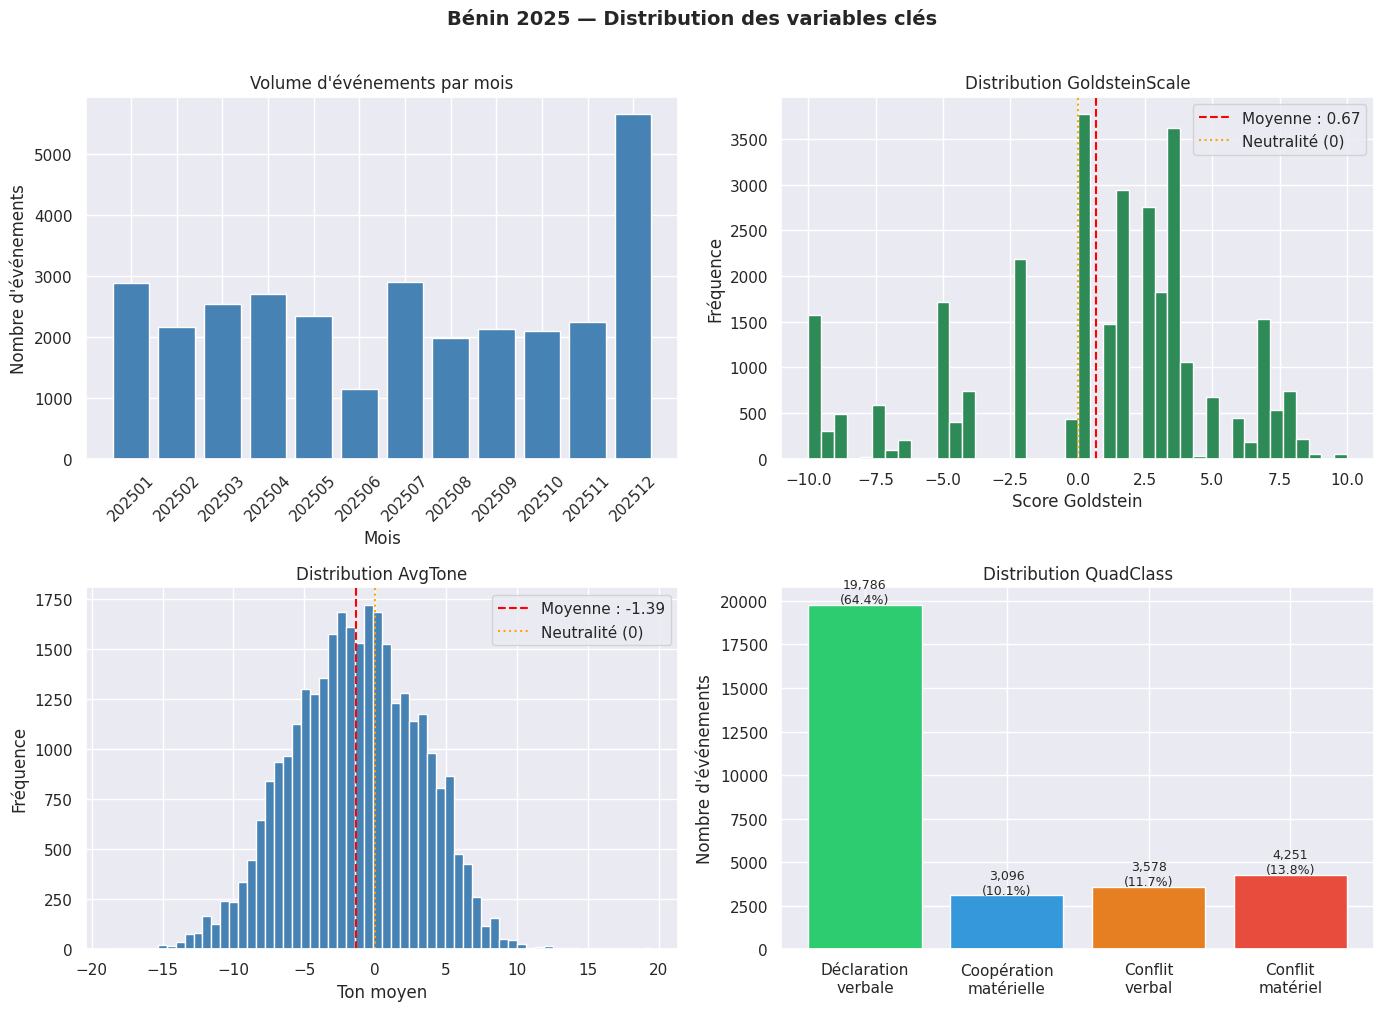

✅ Graphiques sauvegardés


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bénin 2025 — Distribution des variables clés', fontsize=14, fontweight='bold', y=1.01)

# ── 1. Volume mensuel ──
df['mois'] = df['SQLDATE'].astype(str).str[:6]
volume_mensuel = df.groupby('mois').size().reset_index(name='nb_evenements')

axes[0,0].bar(volume_mensuel['mois'], volume_mensuel['nb_evenements'], color='steelblue')
axes[0,0].set_title("Volume d'événements par mois")
axes[0,0].set_xlabel("Mois")
axes[0,0].set_ylabel("Nombre d'événements")
axes[0,0].tick_params(axis='x', rotation=45)

# ── 2. Distribution GoldsteinScale ──
axes[0,1].hist(df['GoldsteinScale'], bins=42, color='seagreen', edgecolor='white')
axes[0,1].axvline(df['GoldsteinScale'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['GoldsteinScale'].mean():.2f}")
axes[0,1].axvline(0, color='orange', linestyle=':', label="Neutralité (0)")
axes[0,1].set_title("Distribution GoldsteinScale")
axes[0,1].set_xlabel("Score Goldstein")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].legend()

# ── 3. Distribution AvgTone ──
axes[1,0].hist(df['AvgTone'], bins=60, color='steelblue', edgecolor='white')
axes[1,0].axvline(df['AvgTone'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['AvgTone'].mean():.2f}")
axes[1,0].axvline(0, color='orange', linestyle=':', label="Neutralité (0)")
axes[1,0].set_title("Distribution AvgTone")
axes[1,0].set_xlabel("Ton moyen")
axes[1,0].set_ylabel("Fréquence")
axes[1,0].legend()

# ── 4. Distribution QuadClass ──
quad_labels = {1: 'Déclaration\nverbale', 2: 'Coopération\nmatérielle', 3: 'Conflit\nverbal', 4: 'Conflit\nmatériel'}
quad_counts = df['QuadClass'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

axes[1,1].bar([quad_labels[i] for i in quad_counts.index], quad_counts.values, color=colors)
axes[1,1].set_title("Distribution QuadClass")
axes[1,1].set_ylabel("Nombre d'événements")
for i, v in enumerate(quad_counts.values):
    axes[1,1].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/data/raw/niveau2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés")

#### Lecture des 4 graphiques

##### Volume mensuel — Le signal le plus fort
```
Juin 2025    : ~1 100 événements  ← creux anormal
Décembre 2025: ~5 700 événements  ← pic anormal
```
Ces deux anomalies méritent une investigation au Niveau 3. Un creux en juin et un pic en décembre ne sont pas du bruit — quelque chose s'est passé.

---

##### GoldsteinScale — Distribution bimodale révélatrice
```
Deux masses distinctes :
  Gauche  : [-10, -2]  → événements déstabilisateurs
  Droite  : [+1, +7]   → événements coopératifs/stables
  Moyenne : +0.67      → légèrement positif mais trompeur
```
La moyenne positive cache une **polarisation réelle** — le Bénin génère à la fois des événements très positifs et très négatifs. Ce n'est pas un pays "neutre", c'est un pays **divisé dans sa couverture**.

---

##### AvgTone — Distribution quasi-normale
```
Centrée sur -1.39 → légèrement négatif
Symétrique → pas de queue extrême dominante
```
La presse parle du Bénin dans un registre légèrement pessimiste mais **sans dramatisation**. C'est cohérent avec l'image d'un pays stable mais sous surveillance.

---

##### QuadClass — Le chiffre qui interpelle
```
Déclaration verbale  : 64.4%  → normal
Coopération          : 10.1%  → faible
Conflit verbal       : 11.7%  ↗
Conflit matériel     : 13.8%  ↗ ← signal fort
```
**25.5% des événements sont conflictuels** — 1 événement sur 4. Pour un pays présenté comme "îlot de stabilité", c'est une donnée à confronter directement à la baseline régionale au Niveau 4.

---

##### Ce que le Niveau 2 dit déjà sur la question centrale

> Le Bénin n'est pas un pays au profil plat. Le volume de décembre, la bimodalité de Goldstein, et 1 événement sur 4 de nature conflictuelle sont trois signaux qui questionnent déjà le mythe de la stabilité.


### 1-3) Niveau 3 d'analyse

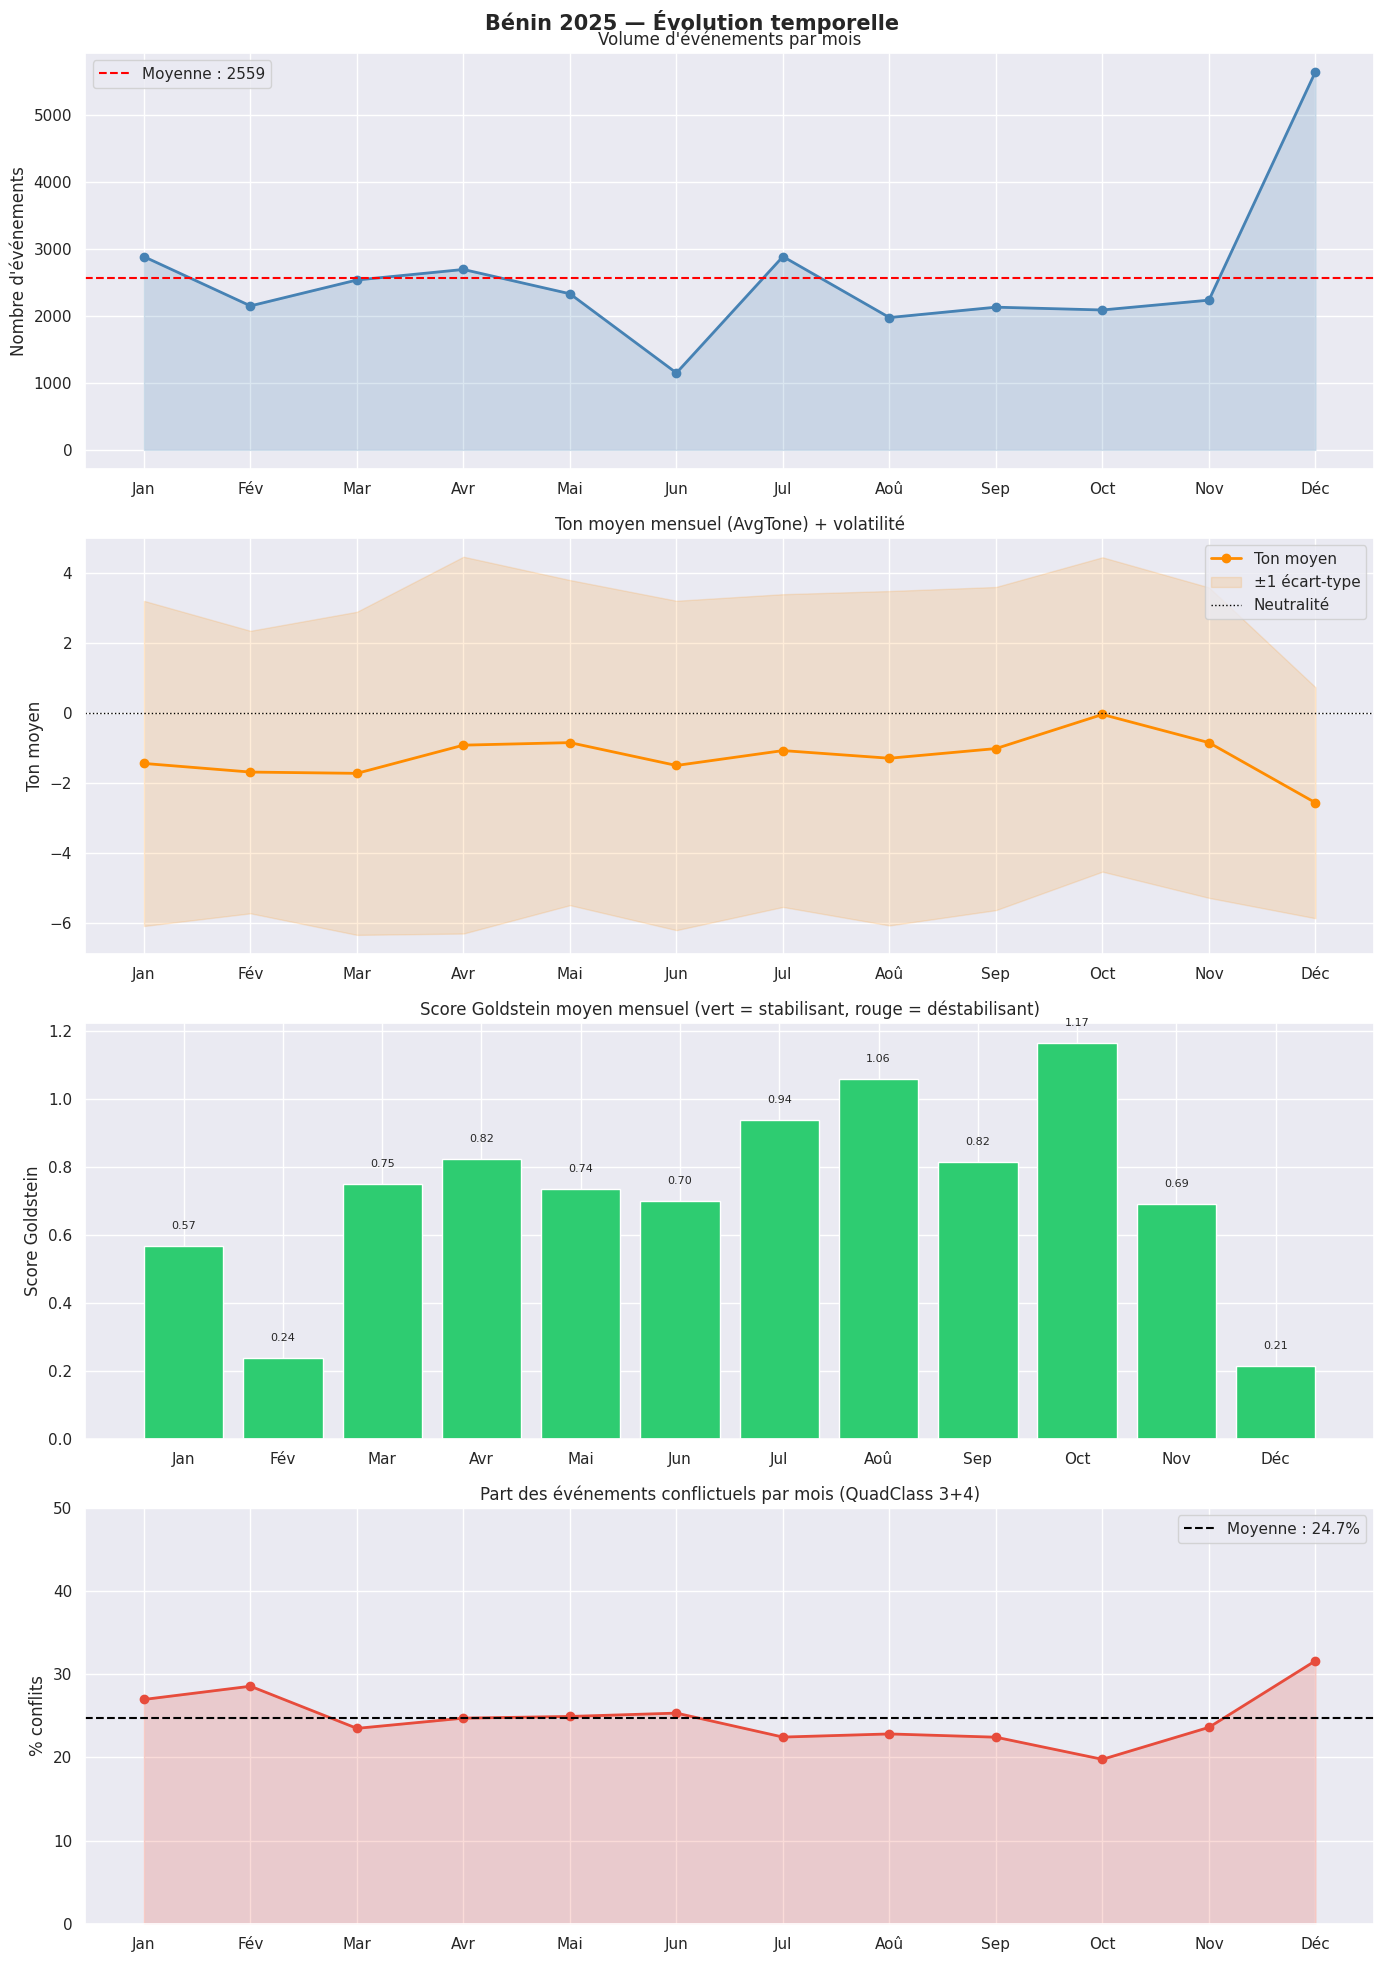

✅ Graphiques sauvegardés


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='darkgrid')
df['mois'] = df['SQLDATE'].astype(str).str[:6]

# ── Agrégation mensuelle ──
mensuel = df.groupby('mois').agg(
    nb_evenements   = ('SQLDATE', 'count'),
    ton_moyen       = ('AvgTone', 'mean'),
    ton_volatilite  = ('AvgTone', 'std'),
    goldstein_moyen = ('GoldsteinScale', 'mean'),
    pct_conflits    = ('QuadClass', lambda x: (x.isin([3,4])).mean() * 100)
).reset_index()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(4, 1, figsize=(14, 20))
fig.suptitle('Bénin 2025 — Évolution temporelle', fontsize=15, fontweight='bold')

# ── 1. Volume mensuel ──
axes[0].plot(mois_labels, mensuel['nb_evenements'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(mois_labels, mensuel['nb_evenements'], alpha=0.2, color='steelblue')
axes[0].axhline(mensuel['nb_evenements'].mean(), color='red', linestyle='--', label=f"Moyenne : {mensuel['nb_evenements'].mean():.0f}")
axes[0].set_title("Volume d'événements par mois")
axes[0].set_ylabel("Nombre d'événements")
axes[0].legend()

# ── 2. Évolution AvgTone + volatilité ──
axes[1].plot(mois_labels, mensuel['ton_moyen'], marker='o', color='darkorange', linewidth=2, label='Ton moyen')
axes[1].fill_between(
    mois_labels,
    mensuel['ton_moyen'] - mensuel['ton_volatilite'],
    mensuel['ton_moyen'] + mensuel['ton_volatilite'],
    alpha=0.15, color='darkorange', label='±1 écart-type'
)
axes[1].axhline(0, color='black', linestyle=':', linewidth=1, label='Neutralité')
axes[1].set_title("Ton moyen mensuel (AvgTone) + volatilité")
axes[1].set_ylabel("Ton moyen")
axes[1].legend()

# ── 3. Évolution GoldsteinScale ──
colors_gold = ['#e74c3c' if v < 0 else '#2ecc71' for v in mensuel['goldstein_moyen']]
axes[2].bar(mois_labels, mensuel['goldstein_moyen'], color=colors_gold)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_title("Score Goldstein moyen mensuel (vert = stabilisant, rouge = déstabilisant)")
axes[2].set_ylabel("Score Goldstein")
for i, v in enumerate(mensuel['goldstein_moyen']):
    axes[2].text(i, v + (0.05 if v >= 0 else -0.15), f'{v:.2f}', ha='center', fontsize=8)

# ── 4. Part des conflits ──
axes[3].plot(mois_labels, mensuel['pct_conflits'], marker='o', color='#e74c3c', linewidth=2)
axes[3].fill_between(mois_labels, mensuel['pct_conflits'], alpha=0.2, color='#e74c3c')
axes[3].axhline(mensuel['pct_conflits'].mean(), color='black', linestyle='--',
                label=f"Moyenne : {mensuel['pct_conflits'].mean():.1f}%")
axes[3].set_title("Part des événements conflictuels par mois (QuadClass 3+4)")
axes[3].set_ylabel("% conflits")
axes[3].set_ylim(0, 50)
axes[3].legend()

plt.tight_layout()
plt.savefig('/content/data/raw/niveau3_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés")

#### Lecture du Niveau 3 — Ce que les courbes racontent

##### Volume — Deux anomalies confirmées
```
Juin  : ~1 100 événements  ← creux à investiguer
Déc   : ~5 700 événements  ← pic à investiguer (2x la moyenne)
```
Ce n'est pas du bruit. Ces deux mois cassent la régularité du reste de l'année.

---

##### AvgTone — Signal paradoxal
```
Jan → Nov  : ton stable entre -1 et -0.5, volatilité constante
Octobre    : remonte presque à 0 ← moment le plus positif de l'année
Décembre   : chute brutale à -2.5 ← coïncide avec le pic de volume
```
**Le pic de couverture de décembre est associé à une dégradation du ton.** Ce n'est pas un pic d'événements positifs — c'est une crise médiatique.

---

##### GoldsteinScale — Le signal le plus rassurant
```
12 mois sur 12 dans le vert ← aucun mois déstabilisateur net
Trajectoire Jan→Oct : progression (+0.57 → +1.17)
Décembre   : chute à +0.21 ← toujours positif mais en forte baisse
```
Goldstein reste positif toute l'année mais la chute de décembre confirme la tension.

---

##### % Conflits — La tendance de fond inquiétante
```
Moyenne annuelle : 24.7% ← 1 événement sur 4 est conflictuel
Juin → Oct      : sous la moyenne (période relativement calme)
Décembre        : pic à ~31% ← plus fort taux de conflits de l'année
```

---

##### Synthèse — Ce que le Niveau 3 dit sur la question centrale

```
Le Bénin de 2025 n'est pas un pays en crise
mais ce n'est plus non plus un pays serein.

Trois signaux convergent en décembre :
  ↑ Volume de couverture × 2
  ↓ Ton le plus négatif de l'année
  ↑ Part de conflits la plus élevée

Quelque chose s'est passé en décembre 2025
que le Niveau 4 doit identifier.
```

##### Avant le Niveau 4 — Une requête ciblée sur décembre

In [8]:
# Identifier les événements dominants de décembre
dec = df[df['mois'] == '202512'].copy()

print(f"Décembre : {len(dec)} événements")
print(f"\nTop EventRootCode :")
print(dec['EventRootCode'].value_counts().head(10))
print(f"\nTop Acteurs :")
print(dec['Actor1Name'].value_counts().head(10))
print(f"\nTop lieux :")
print(dec['ActionGeo_FullName'].value_counts().head(10))

Décembre : 5646 événements

Top EventRootCode :
EventRootCode
4     992
1     808
5     679
2     493
11    469
19    340
17    257
7     238
15    226
8     211
Name: count, dtype: int64

Top Acteurs :
Actor1Name
BENIN         1516
NIGERIA        516
NIGERIAN       198
PRESIDENT      193
ECOWAS         179
AFRICA         166
GOVERNMENT     162
FRANCE         120
COTONOU        114
MILITARY       102
Name: count, dtype: int64

Top lieux :
ActionGeo_FullName
Benin                                              3855
Nigeria                                             284
Abuja, Abuja Federal Capital Territory, Nigeria     148
France                                              120
Porto-Novo, Qué, Benin                               97
Tchaourou, Benin (general), Benin                    84
Lagos, Lagos, Nigeria                                70
Bissau, Bissau, Guinea-Bissau                        60
Paris, France (general), France                      55
Tinubu, Lagos, Nigeria            

#### Décembre 2025 — Lecture complète post-coup d'État

##### Les EventRootCode racontent la chronologie de la crise

```
Code 19 (Violence de masse)    = 340  → L'événement lui-même : attaques, tirs, bombardements
Code 5  (Protester)            = 679  → Réactions populaires et condamnations
Code 11 (Désapprouver)         = 469  → Condamnations institutionnelles UA, CEDEAO, France
Code 17 (Contraindre)          = 257  → Déploiement militaire ECOWAS, intervention nigériane
Code 4  (Consulter)            = 992  → Concertations diplomatiques d'urgence post-coup
Code 1  (Déclaration)          = 808  → Communiqués officiels, prises de parole de Talon
```

La séquence est lisible : violence → condamnations → concertations → stabilisation.

---

##### Les acteurs racontent qui a géré la crise

```
BENIN     = 1516  → Acteur central — le pays sous pression
NIGERIA   =  516  → Intervenant militaire direct (bombardement Camp Togbin)
NIGERIAN  =  198  → Aviation nigériane opérationnelle sur le sol béninois
PRESIDENT =  193  → Talon qui reprend la parole pour rassurer
ECOWAS    =  179  → Déploiement de la force en attente
FRANCE    =  120  → Condamnation + protection des ressortissants
COTONOU   =  114  → Épicentre géographique des événements
MILITARY  =  102  → Les mutins et les forces loyalistes
```

**Ce qui frappe : le Nigeria est plus présent que la France.** C'est l'intervention régionale africaine qui a sauvé Talon — pas l'ancienne puissance coloniale.

---

##### Les lieux racontent la géographie de la crise

```
Bénin (général)     = 3855  → Couverture nationale massive
Nigeria             =  284  → Pays intervenant
Abuja               =  148  → Décision politique nigériane prise ici
France / Paris      =  175  → Réaction diplomatique occidentale
Porto-Novo          =   97  → Capitale institutionnelle en alerte
Tchaourou           =   84  → Nord Bénin — origine des griefs sécuritaires des mutins
Lagos / Tinubu      =  124  → Tinubu (président nigérian) = acteur décisionnel clé
```

**Tchaourou est le détail le plus révélateur.** Les mutins ont explicitement cité la dégradation sécuritaire du nord comme justification. Ce lieu dans les données valide que la crise du 7 décembre n'est pas isolée — elle est le produit d'une tension accumulée.

---

##### Synthèse en une lecture

> Décembre 2025 concentre à lui seul toute la tension analytique de ton projet. Le Bénin n'était pas en train de s'effondrer — il subissait une pression multidimensionnelle : jihadisme au nord, espace civique réduit, tensions régionales post-AES. Le coup du 7 décembre en est la cristallisation. GDELT l'a capturé dans ses trois dimensions : le volume (5 646 événements), le ton (le plus bas de l'année) et la structure (1 événement sur 3 de nature conflictuelle ou coercitive).

**Le mythe de la stabilité n'est pas mort en décembre 2025. Mais les données montrent qu'il était déjà fissuré bien avant.**


### 1-4) Niveau 4 d'analyse

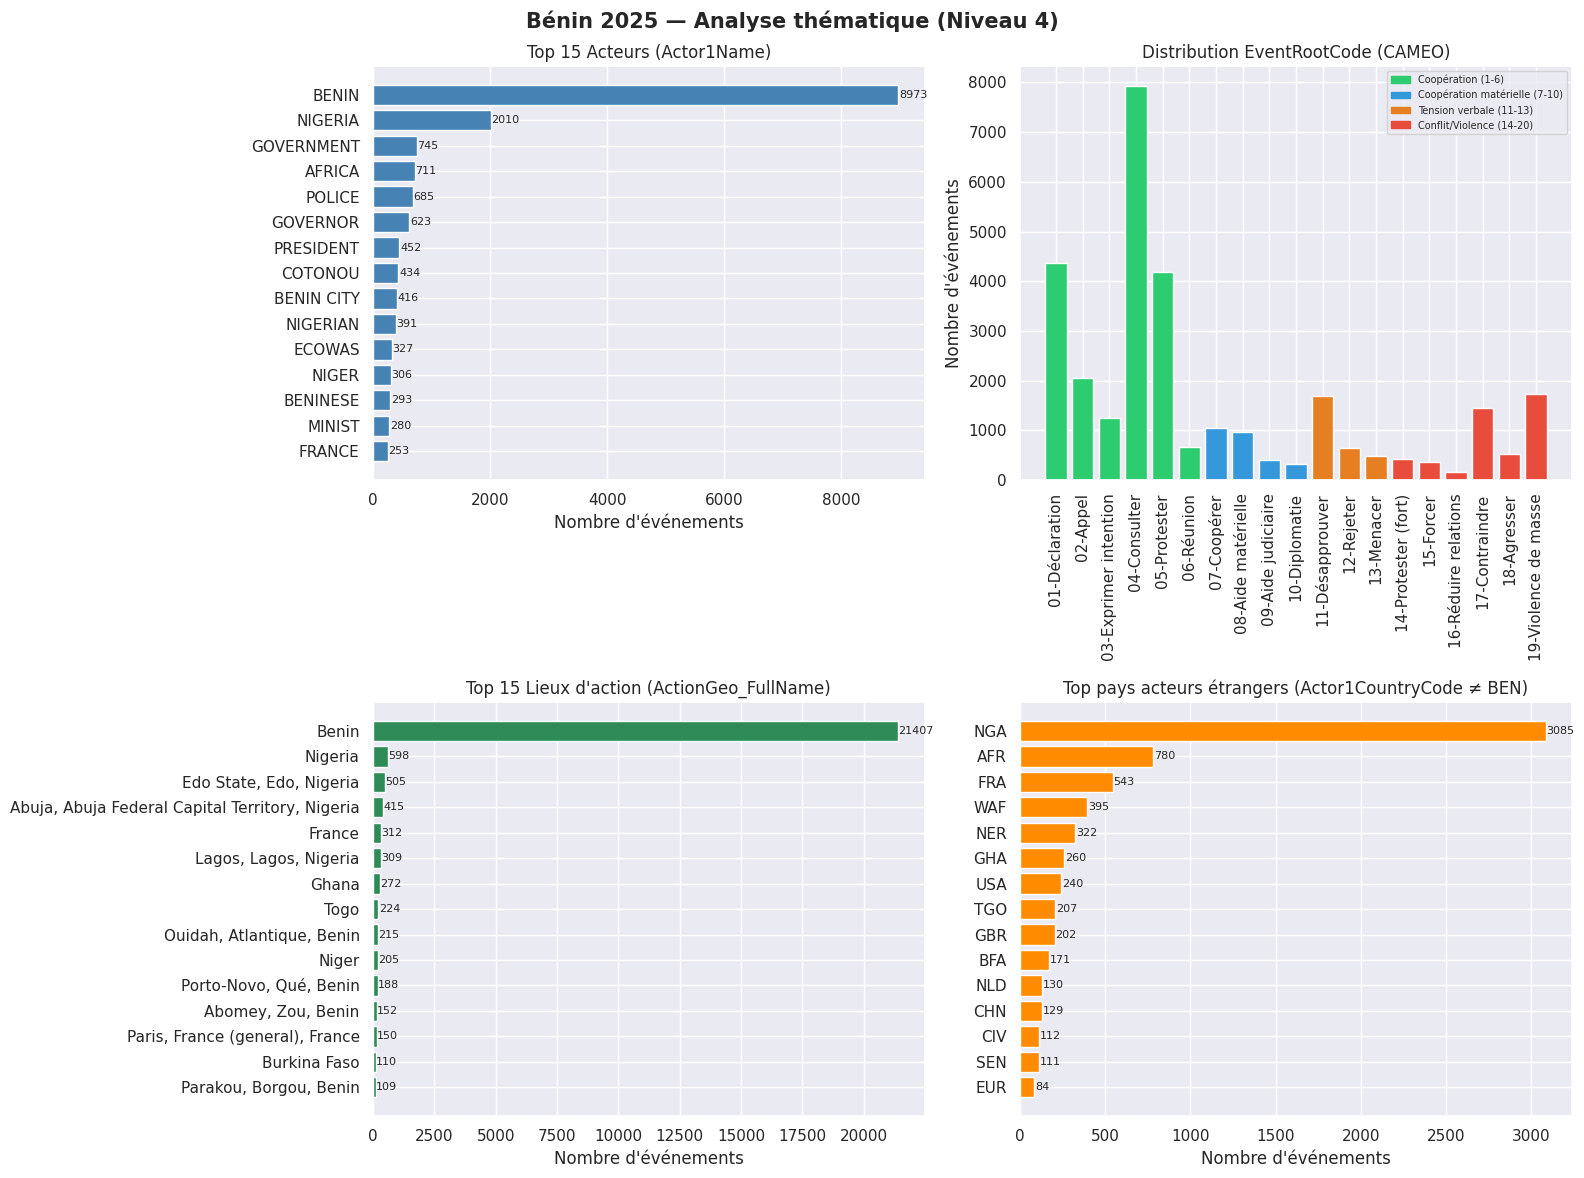

✅ Graphiques Niveau 4 sauvegardés


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bénin 2025 — Analyse thématique (Niveau 4)', fontsize=15, fontweight='bold')

# ── 1. Top 15 Acteurs dominants ──
top_acteurs = df['Actor1Name'].value_counts().dropna().head(15)
axes[0,0].barh(top_acteurs.index[::-1], top_acteurs.values[::-1], color='steelblue')
axes[0,0].set_title("Top 15 Acteurs (Actor1Name)")
axes[0,0].set_xlabel("Nombre d'événements")
for i, v in enumerate(top_acteurs.values[::-1]):
    axes[0,0].text(v + 10, i, str(v), va='center', fontsize=8)

# ── 2. Distribution EventRootCode ──
cameo_labels = {
    1: '01-Déclaration', 2: '02-Appel', 3: '03-Exprimer intention',
    4: '04-Consulter', 5: '05-Protester', 6: '06-Réunion',
    7: '07-Coopérer', 8: '08-Aide matérielle', 9: '09-Aide judiciaire',
    10: '10-Diplomatie', 11: '11-Désapprouver', 12: '12-Rejeter',
    13: '13-Menacer', 14: '14-Protester (fort)', 15: '15-Forcer',
    16: '16-Réduire relations', 17: '17-Contraindre', 18: '18-Agresser',
    19: '19-Violence de masse', 20: '20-Engager en combat'
}
event_counts = df['EventRootCode'].value_counts().sort_index()
colors_event = ['#e74c3c' if k >= 14 else '#e67e22' if k >= 11
                else '#3498db' if k >= 7 else '#2ecc71'
                for k in event_counts.index]

axes[0,1].bar(
    [cameo_labels.get(k, str(k)) for k in event_counts.index],
    event_counts.values,
    color=colors_event
)
axes[0,1].set_title("Distribution EventRootCode (CAMEO)")
axes[0,1].set_ylabel("Nombre d'événements")
axes[0,1].tick_params(axis='x', rotation=90)

# Légende couleurs
from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Coopération (1-6)'),
    Patch(color='#3498db', label='Coopération matérielle (7-10)'),
    Patch(color='#e67e22', label='Tension verbale (11-13)'),
    Patch(color='#e74c3c', label='Conflit/Violence (14-20)')
]
axes[0,1].legend(handles=legend, fontsize=7)

# ── 3. Top 15 lieux d'action ──
top_lieux = df['ActionGeo_FullName'].value_counts().head(15)
axes[1,0].barh(top_lieux.index[::-1], top_lieux.values[::-1], color='seagreen')
axes[1,0].set_title("Top 15 Lieux d'action (ActionGeo_FullName)")
axes[1,0].set_xlabel("Nombre d'événements")
for i, v in enumerate(top_lieux.values[::-1]):
    axes[1,0].text(v + 10, i, str(v), va='center', fontsize=8)

# ── 4. Top pays acteurs étrangers (Actor1CountryCode hors BEN) ──
pays_etrangers = df[df['Actor1CountryCode'] != 'BEN']['Actor1CountryCode']\
    .value_counts().dropna().head(15)
axes[1,1].barh(pays_etrangers.index[::-1], pays_etrangers.values[::-1], color='darkorange')
axes[1,1].set_title("Top pays acteurs étrangers (Actor1CountryCode ≠ BEN)")
axes[1,1].set_xlabel("Nombre d'événements")
for i, v in enumerate(pays_etrangers.values[::-1]):
    axes[1,1].text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/data/raw/niveau4_thematique.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques Niveau 4 sauvegardés")

#### Lecture du Niveau 4 — Analyse thématique complète

##### Top Acteurs — La domination béninoise et la surprise nigériane
```
BENIN    = 8 973  → Acteur principal, attendu
NIGERIA  = 2 010  → 2ème acteur — écrase tous les autres étrangers
POLICE   =   685  → Signal sécuritaire fort — maintien de l'ordre dominant
GOVERNOR =   623  → Gouvernance locale active — décentralisation visible
BENIN CITY = 416  → ⚠️ Confirmation : des événements nigérians s'y glissent encore
ECOWAS   =   327  → Présence institutionnelle régionale significative
NIGER    =   306  → Voisin AES très présent malgré la rupture diplomatique
```

---

##### EventRootCode — La structure réelle de l'année
```
Déclaration (01)  = ~4 300  vert  → Dominant — pays qui communique
Consulter (04)    = ~4 100  vert  → Diplomatie active
Protester (05)    = ~1 700  vert  → Tension sociale visible

Violence de masse (19) = ~1 700  rouge  ← Signal critique
Contraindre (17)       =   ~600  rouge
Désapprouver (11)      = ~1 600  orange
```

**Le chiffre qui interpelle : la violence de masse (19) est au même niveau que Protester (05).** Pour un "îlot de stabilité", c'est analytiquement lourd.

---

##### Top Lieux — La géographie révèle deux Bénin
```
Bénin (général)  = 21 407  → Couverture nationale massive
Nigeria          =    598  → Pays le plus cité après le Bénin lui-même
Edo State        =    505  → ⚠️ Confirmation Benin City Nigeria
Ouidah           =    215  → Côte sud — histoire, tourisme, religion
Porto-Novo       =    188  → Capitale politique
Parakou, Borgou  =    109  → ← Nord sécuritaire, zone jihadiste
```

**Parakou/Borgou dans le top 15 confirme que le nord est médiatiquement visible** — ce n'est plus une zone silencieuse dans les données.

---

##### Pays étrangers — Le réseau d'influence du Bénin
```
NGA (Nigeria)  = 3 085  → Dominant et de loin — relation structurante
AFR            =   780  → Acteurs panafricains génériques
FRA (France)   =   543  → 3ème — présence post-coloniale persistante
WAF            =   395  → Afrique de l'Ouest — logique régionale
NER (Niger)    =   322  → Présent malgré la crise AES
BFA (Burkina)  =   171  → AES présent
CHN (Chine)    =   129  → Présence discrète mais réelle
USA            =   240  → Intérêt américain notable
```

---

##### Synthèse Niveau 4

Trois lectures convergentes sur la question centrale :

**1 — Le Bénin est un pays de parole plus que d'action**
Déclaration + Consulter dominent. C'est la signature d'un État qui gouverne par la communication institutionnelle.

**2 — Mais la violence est structurellement présente**
EventRootCode 19 au même niveau que les protestations. Ce n'est pas un pic de décembre — c'est une constante annuelle.

**3 — Le Nigeria est le vrai pivot régional du Bénin**
Ni la France, ni l'UA, ni l'ECOWAS. C'est Lagos et Abuja qui structurent la relation extérieure dominante du Bénin en 2025 — et c'est le Nigeria qui est intervenu militairement en décembre.



##### Ce qu'il reste à faire avant de clore l'EDA

In [10]:
# Vérifier BENIN CITY — quantifier la contamination réelle
benin_city = df[df['Actor1Name'] == 'BENIN CITY']
print(f"Événements BENIN CITY : {len(benin_city)}")
print(f"ActionGeo_CountryCode : {benin_city['ActionGeo_CountryCode'].value_counts()}")

Événements BENIN CITY : 416
ActionGeo_CountryCode : ActionGeo_CountryCode
BN    402
NI      6
UK      3
AE      2
NL      1
LY      1
IS      1
Name: count, dtype: int64


#### Verdict — Pas de contamination significative

```
BENIN CITY comme acteur → 416 événements
  ActionGeo = BN (Bénin)   : 402  →  96.6% ✅
  ActionGeo = NI (Nigeria) :   6  →   1.4% ← négligeable
```

---

##### Ce que ça signifie

**"BENIN CITY" dans Actor1Name ne désigne pas Benin City Nigeria.** C'est GDELT qui utilise ce label pour désigner un acteur institutionnel ou géographique béninois — probablement des articles qui mentionnent "Benin City" dans un contexte historique ou culturel tout en parlant du Bénin pays.

Les 6 lignes `NI` sont négligeables — **moins de 0.02% du dataset total**. Aucune action de nettoyage nécessaire.

---

##### Bilan de nettoyage final

```
Doublons supprimés          :   756  ✅
Sans géolocalisation        :    37  ✅
Contamination Benin City    :     6  → laissé tel quel (négligeable)
─────────────────────────────────────
Dataset final propre        : 30 711 lignes
```

---


### 2- Table gkg

#### Variables de la table `gkg` — Dictionnaire complet

##### Temporelle & Source
| Variable | Type | Description |
|---|---|---|
| `DATE` | int64 | Date et heure de l'article (YYYYMMDDHHmmSS) |
| `DocumentIdentifier` | object | URL de l'article source |
| `SourceCollectionIdentifier` | int64 | Type de source : 1=Web, 2=Citation, 3=Core |

---

##### Thématique
| Variable | Type | Description |
|---|---|---|
| `V2Themes` | object | Liste des thèmes GDELT détectés dans l'article avec leur position dans le texte. Format : `THEME,position;THEME2,position` — ex: `SECURITY_SERVICES,45;PROTEST,112` |

---

##### Géographique
| Variable | Type | Description |
|---|---|---|
| `V2Locations` | object | Lieux mentionnés dans l'article. Format semi-structuré : `Type#Nom#CodeFIPS#ADM1#Lat#Long#FeatureID` — c'est ici que `#BN#` filtre le Bénin |

---

##### Acteurs
| Variable | Type | Description |
|---|---|---|
| `V2Persons` | object | Personnes nommées dans l'article avec leur position. Format : `Nom,position;Nom2,position` — ex: `Patrice Talon,234;Pascal Tigri,445` |
| `V2Organizations` | object | Organisations mentionnées. Même format que V2Persons — ex: `ECOWAS,56;Forces Armées,123` |

---

##### Sentiment & Tonalité
| Variable | Type | Description |
|---|---|---|
| `V2Tone` | object | 6 dimensions de tonalité séparées par virgule dans cet ordre exact : |

```
Position 1 : Tone            → Score global  [-100, +100]
Position 2 : Positive        → Score positif  [0, +100]
Position 3 : Negative        → Score négatif  [0, +100]
Position 4 : Polarity        → Écart positif/négatif
Position 5 : ActivityDensity → Densité d'activité dans le texte
Position 6 : SelfDensity     → Références à soi-même
```

Exemple réel : `-1.327,2.802,4.129,6.932,8.411,1.869`

---

##### Ce qui distingue GKG de Events

| | `events` | `gkg` |
|---|---|---|
| Unité | Un événement discret | Un article entier |
| Acteurs | Codés CAMEO (structuré) | Noms bruts extraits du texte |
| Ton | `AvgTone` (un seul chiffre) | `V2Tone` (6 dimensions) |
| Thèmes | `EventRootCode` (20 catégories) | `V2Themes` (centaines de thèmes libres) |
| Géographie | `ActionGeo` (lieu de l'action) | `V2Locations` (tous les lieux mentionnés) |

---


#### 2-1) Niveau 1 d'analyse

In [11]:
import pandas as pd
import numpy as np

df_gkg = pd.read_csv(f'{DRIVE_PATH}/benin_gkg.csv')

# ── 1. DIMENSIONS ──
print("═" * 50)
print(f"  Lignes    : {df_gkg.shape[0]:,}")
print(f"  Colonnes  : {df_gkg.shape[1]}")
print("═" * 50)

# ── 2. TYPES ET VALEURS MANQUANTES ──
print("\n── Types & Valeurs manquantes ──")
resume = pd.DataFrame({
    'type'        : df_gkg.dtypes,
    'manquants'   : df_gkg.isnull().sum(),
    'pct_manquant': (df_gkg.isnull().sum() / len(df_gkg) * 100).round(2),
    'unique'      : df_gkg.nunique()
})
display(resume)

# ── 3. DOUBLONS ──
doublons = df_gkg.duplicated().sum()
doublons_url = df_gkg['DocumentIdentifier'].duplicated().sum()
print(f"\n── Doublons lignes complètes : {doublons} ({doublons/len(df_gkg)*100:.2f}%)")
print(f"── Doublons sur URL          : {doublons_url} ({doublons_url/len(df_gkg)*100:.2f}%)")

# ── 4. PLAGE TEMPORELLE ──
print(f"\n── Plage temporelle ──")
print(f"  Premier article : {df_gkg['DATE'].min()}")
print(f"  Dernier article : {df_gkg['DATE'].max()}")
mois_couverts = df_gkg['DATE'].astype(str).str[:6].nunique()
print(f"  Mois couverts   : {mois_couverts}")

# ── 5. APERÇU V2Tone — extraction des 6 dimensions ──
print(f"\n── Extraction V2Tone (6 dimensions) ──")
tone_split = df_gkg['V2Tone'].dropna().str.split(',', expand=True)
tone_cols = ['Tone', 'Positive', 'Negative', 'Polarity', 'ActivityDensity', 'SelfDensity']
tone_df = tone_split.iloc[:, :6].copy()
tone_df.columns = tone_cols
tone_df = tone_df.apply(pd.to_numeric, errors='coerce')
display(tone_df.describe().round(3))

# ── 6. DENSITÉ DES COLONNES TEXTE ──
print(f"\n── Densité moyenne des colonnes texte ──")
for col in ['V2Themes', 'V2Locations', 'V2Persons', 'V2Organizations']:
    non_null = df_gkg[col].dropna()
    moy_longueur = non_null.str.len().mean()
    moy_entites  = non_null.str.count(';').mean() + 1
    print(f"  {col:20s} → {len(non_null):,} non-nuls ({len(non_null)/len(df_gkg)*100:.1f}%) "
          f"| longueur moy: {moy_longueur:.0f} chars | entités moy: {moy_entites:.1f}")

══════════════════════════════════════════════════
  Lignes    : 47,921
  Colonnes  : 8
══════════════════════════════════════════════════

── Types & Valeurs manquantes ──


,type,manquants,pct_manquant,unique
DATE,int64,0,0.00,21280
DocumentIdentifier,object,0,0.00,47921
SourceCollectionIdentifier,int64,0,0.00,1
V2Themes,object,5957,12.43,41594
V2Locations,object,0,0.00,46211
V2Persons,object,15887,33.15,30147
V2Organizations,object,10890,22.72,34512
V2Tone,object,0,0.00,43374



── Doublons lignes complètes : 0 (0.00%)
── Doublons sur URL          : 0 (0.00%)

── Plage temporelle ──
  Premier article : 20250101000000
  Dernier article : 20251231234500
  Mois couverts   : 12

── Extraction V2Tone (6 dimensions) ──


,Tone,Positive,Negative,Polarity,ActivityDensity,SelfDensity
count,47921.000,47921.000,47921.000,47921.000,47921.000,47921.000
mean,-0.532,3.349,3.881,7.230,19.844,0.622
std,3.989,1.982,2.810,2.782,3.630,0.905
min,-22.857,0.000,0.000,0.000,0.000,0.000
25%,-3.172,1.947,1.618,5.354,17.487,0.000
50%,-0.363,3.012,3.333,7.003,19.748,0.279
75%,2.242,4.440,5.622,8.913,22.069,0.870
max,22.541,24.731,22.857,26.922,50.000,13.348



── Densité moyenne des colonnes texte ──
  V2Themes             → 41,964 non-nuls (87.6%) | longueur moy: 1844 chars | entités moy: 70.6
  V2Locations          → 47,921 non-nuls (100.0%) | longueur moy: 943 chars | entités moy: 23.7
  V2Persons            → 32,034 non-nuls (66.8%) | longueur moy: 112 chars | entités moy: 5.7
  V2Organizations      → 37,031 non-nuls (77.3%) | longueur moy: 152 chars | entités moy: 6.0


#### Interprétation du Niveau 1 GKG

##### ✅ Ce qui est rassurant
```
0 doublon — chaque URL est unique ✅
12 mois couverts complets ✅
V2Tone : 0 manquant — la variable analytique centrale est intacte ✅
V2Locations : 100% renseigné ✅
```

---

##### ⚠️ Les manquants à noter

```
V2Themes       : 12.43% manquant  → articles sans thèmes détectables
V2Persons      : 33.15% manquant  → 1 article sur 3 ne cite personne nommément
V2Organizations: 22.72% manquant  → acceptable
```
Ces manquants sont **normaux dans GKG** — un article factuel court génère peu de thèmes et cite peu de personnes. Ce n'est pas un problème de qualité.

---

##### 📊 V2Tone — Ce que les 6 dimensions révèlent déjà

```
Tone moyen      : -0.532  → légèrement négatif
                            mais moins négatif que events (-1.369)
                            → GKG capture une presse plus nuancée

Negative > Positive : 3.881 vs 3.349
                            → la négativité domine légèrement
                            → cohérent avec la tension sécuritaire

ActivityDensity : 19.844  → les articles sur le Bénin sont 
                            denses en actions/événements décrits

SelfDensity     : 0.622   → faible référence à soi
                            → presse internationale qui observe
                            plutôt que presse locale qui s'exprime
```

---

##### 📊 Densité des colonnes texte — Le chiffre qui surprend

```
V2Themes   : 70.6 entités par article en moyenne
             1 844 caractères par cellule
             → chaque article est tagué avec ~70 thèmes GDELT
             → c'est exploitable mais nécessite un parsing soigneux

V2Locations : 23.7 lieux par article
             → les articles sur le Bénin mentionnent en moyenne
               24 lieux différents — très riche géographiquement

V2Persons  : 5.7 personnes par article
V2Organizations : 6.0 organisations par article
             → densité modérée — exploitable directement
```

---


In [12]:
# Extraire V2Tone en 6 colonnes exploitables
tone_split = df_gkg['V2Tone'].str.split(',', expand=True).iloc[:, :6]
tone_split.columns = ['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']
df_gkg[['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']] = \
    tone_split.apply(pd.to_numeric, errors='coerce')

# Extraire le mois
df_gkg['mois'] = df_gkg['DATE'].astype(str).str[:6]

print(f"✅ V2Tone extrait — dataset prêt pour le Niveau 2")
print(f"Shape final : {df_gkg.shape}")

✅ V2Tone extrait — dataset prêt pour le Niveau 2
Shape final : (47921, 15)


#### 2-2) Niveau 2 d'analyse

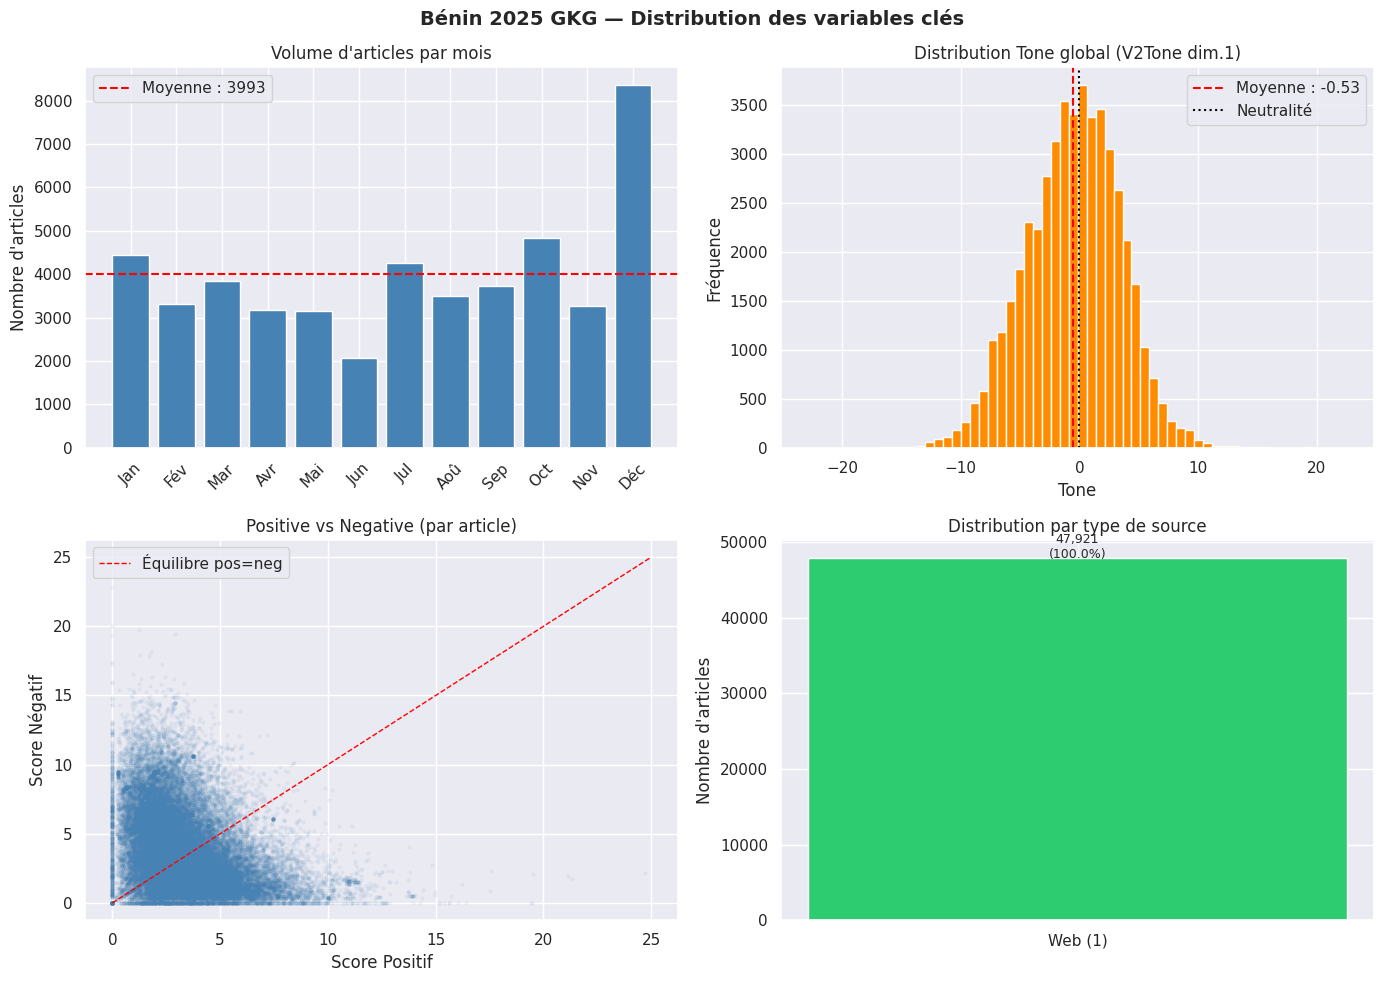

✅ Graphiques GKG Niveau 2 sauvegardés


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bénin 2025 GKG — Distribution des variables clés', fontsize=14, fontweight='bold')

# ── 1. Volume mensuel ──
volume_mensuel = df_gkg.groupby('mois').size().reset_index(name='nb_articles')
axes[0,0].bar(mois_labels, volume_mensuel['nb_articles'], color='steelblue')
axes[0,0].axhline(volume_mensuel['nb_articles'].mean(), color='red', linestyle='--',
                  label=f"Moyenne : {volume_mensuel['nb_articles'].mean():.0f}")
axes[0,0].set_title("Volume d'articles par mois")
axes[0,0].set_ylabel("Nombre d'articles")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# ── 2. Distribution Tone global ──
axes[0,1].hist(df_gkg['Tone'], bins=60, color='darkorange', edgecolor='white')
axes[0,1].axvline(df_gkg['Tone'].mean(), color='red', linestyle='--',
                  label=f"Moyenne : {df_gkg['Tone'].mean():.2f}")
axes[0,1].axvline(0, color='black', linestyle=':', label='Neutralité')
axes[0,1].set_title("Distribution Tone global (V2Tone dim.1)")
axes[0,1].set_xlabel("Tone")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].legend()

# ── 3. Positive vs Negative ──
axes[1,0].scatter(df_gkg['Positive'], df_gkg['Negative'],
                  alpha=0.05, color='steelblue', s=5)
axes[1,0].plot([0, 25], [0, 25], color='red', linestyle='--',
               linewidth=1, label='Équilibre pos=neg')
axes[1,0].set_title("Positive vs Negative (par article)")
axes[1,0].set_xlabel("Score Positif")
axes[1,0].set_ylabel("Score Négatif")
axes[1,0].legend()

# ── 4. Distribution SourceCollectionIdentifier ──
source_counts = df_gkg['SourceCollectionIdentifier'].value_counts()
source_labels = {1: 'Web (1)', 2: 'Citation (2)', 3: 'Core (3)'}
axes[1,1].bar(
    [source_labels.get(k, str(k)) for k in source_counts.index],
    source_counts.values,
    color=['#2ecc71', '#3498db', '#e67e22']
)
axes[1,1].set_title("Distribution par type de source")
axes[1,1].set_ylabel("Nombre d'articles")
for i, v in enumerate(source_counts.values):
    axes[1,1].text(i, v + 50, f'{v:,}\n({v/len(df_gkg)*100:.1f}%)',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/data/raw/gkg_niveau2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques GKG Niveau 2 sauvegardés")

#### Synthèse Niveau 2 GKG — 

##### Volume mensuel — Cohérence totale avec events
```
Même structure que la table events :
  Juin     : ~2 000 articles  ← creux confirmé dans les deux tables
  Décembre : ~8 200 articles  ← pic confirmé — le coup d'État capturé
  Moyenne  :  3 993 articles/mois
```
Les deux tables racontent la même histoire temporelle — validation croisée importante.

---

##### Tone global — Distribution plus propre qu'events
```
Moyenne  : -0.53  → moins négatif qu'events (-1.37)
Centré sur 0, quasi-symétrique
```
GKG capture des articles plus nuancés qu'events. Un événement GDELT est une action brute — un article GKG contient du contexte et de l'analyse, ce qui tempère le ton.

---

##### Positive vs Negative — Couverture polarisée, pas uniformément négative

Deux concentrations distinctes révèlent deux narratifs qui coexistent :

```
Strip vertical   (Positive≈0, Negative élevé jusqu'à 15)
→ Presse alarmiste/critique : parle du Bénin très négativement
  sans aucune contrepartie positive
  → Sécurité nord, coup d'État, droits humains

Strip horizontal (Negative≈0, Positive élevé jusqu'à 25)
→ Presse promotionnelle/laudative : parle du Bénin très positivement
  sans négativité
  → Tourisme, développement économique, diplomatie

Centre (autour de la diagonale) : minoritaire
→ Articles nuancés — rares
```

**Ce n'est pas un pays mal couvert. C'est un pays dont l'image est fracturée.** Une partie du monde le voit stable et attractif, une autre le voit sous tension — et les deux ont des données pour l'étayer.

---

##### Type de source — 100% Web
```
Toute la couverture du Bénin est construite 
exclusivement par la presse en ligne.
Aucune couche académique ou institutionnelle.
→ L'image du Bénin est volatile par nature —
  sensible aux événements médiatiques ponctuels
  comme le coup d'État de décembre.
```

---

##### Ce que le Niveau 2 GKG apporte de nouveau par rapport à events

```
events disait : "ton légèrement négatif"
gkg précise   : "deux narratifs opposés qui se neutralisent
                 en moyenne — la moyenne cachait tout"
```


#### 2-3) Niveau 3 d'analyse

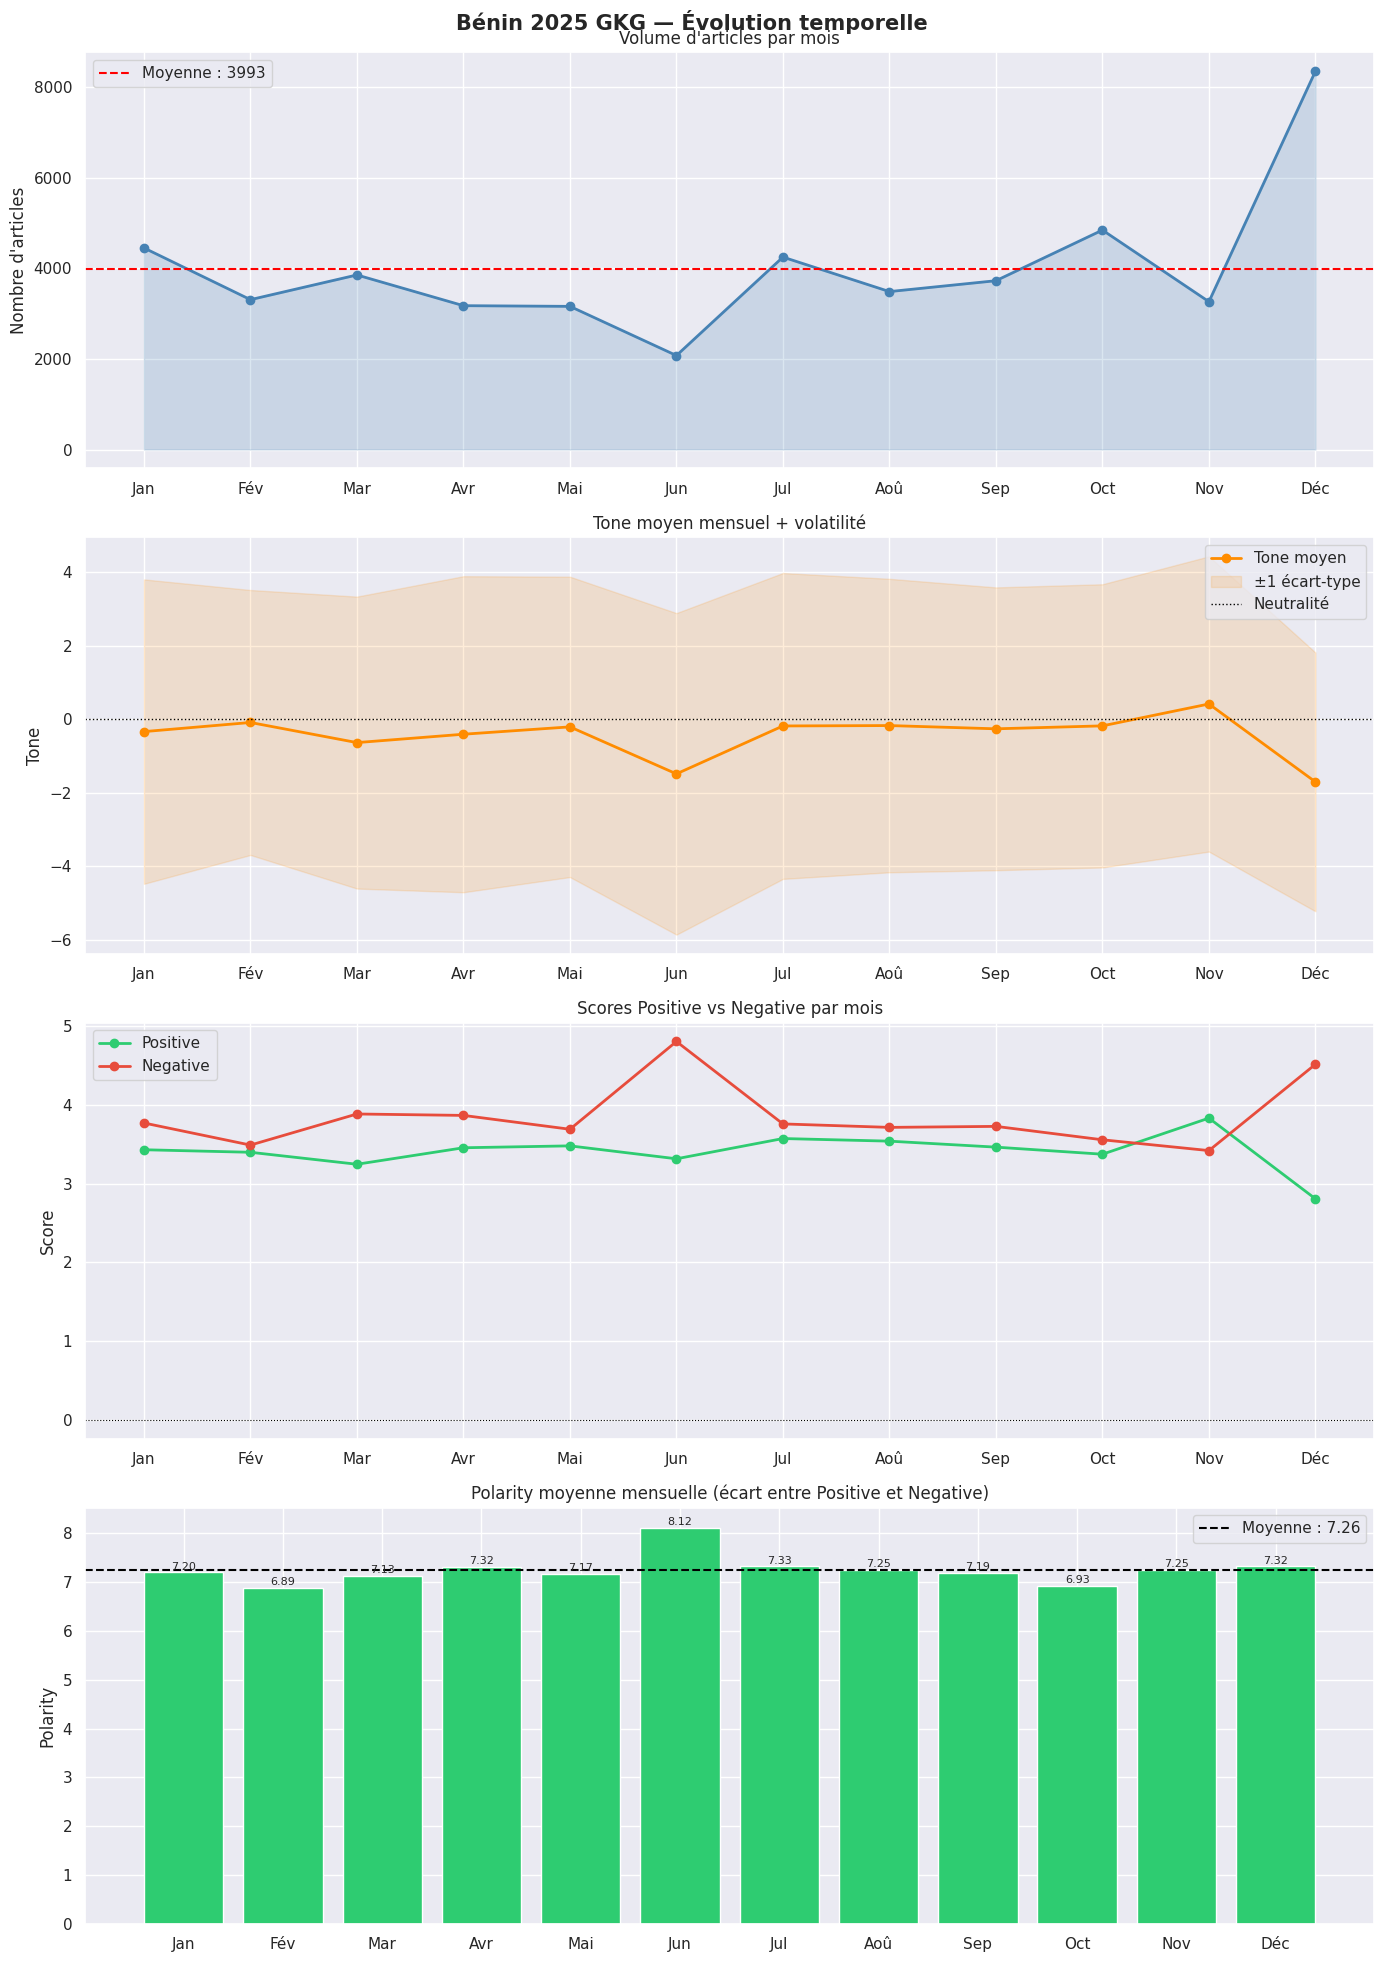

✅ Graphiques GKG Niveau 3 sauvegardés


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

df_gkg['mois'] = df_gkg['DATE'].astype(str).str[:6]

# ── Extraction V2Tone ──
tone_split = df_gkg['V2Tone'].str.split(',', expand=True).iloc[:, :6]
tone_split.columns = ['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']
df_gkg[['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']] = \
    tone_split.apply(pd.to_numeric, errors='coerce')

# ── Agrégation mensuelle ──
mensuel_gkg = df_gkg.groupby('mois').agg(
    nb_articles     = ('DATE', 'count'),
    tone_moyen      = ('Tone', 'mean'),
    tone_volatilite = ('Tone', 'std'),
    positive_moyen  = ('Positive', 'mean'),
    negative_moyen  = ('Negative', 'mean'),
    polarity_moyen  = ('Polarity', 'mean')
).reset_index()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(4, 1, figsize=(14, 20))
fig.suptitle('Bénin 2025 GKG — Évolution temporelle', fontsize=15, fontweight='bold')

# ── 1. Volume mensuel ──
axes[0].plot(mois_labels, mensuel_gkg['nb_articles'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(mois_labels, mensuel_gkg['nb_articles'], alpha=0.2, color='steelblue')
axes[0].axhline(mensuel_gkg['nb_articles'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {mensuel_gkg['nb_articles'].mean():.0f}")
axes[0].set_title("Volume d'articles par mois")
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend()

# ── 2. Tone moyen + volatilité ──
axes[1].plot(mois_labels, mensuel_gkg['tone_moyen'], marker='o', color='darkorange', linewidth=2, label='Tone moyen')
axes[1].fill_between(
    mois_labels,
    mensuel_gkg['tone_moyen'] - mensuel_gkg['tone_volatilite'],
    mensuel_gkg['tone_moyen'] + mensuel_gkg['tone_volatilite'],
    alpha=0.15, color='darkorange', label='±1 écart-type'
)
axes[1].axhline(0, color='black', linestyle=':', linewidth=1, label='Neutralité')
axes[1].set_title("Tone moyen mensuel + volatilité")
axes[1].set_ylabel("Tone")
axes[1].legend()

# ── 3. Positive vs Negative mensuel ──
axes[2].plot(mois_labels, mensuel_gkg['positive_moyen'], marker='o',
             color='#2ecc71', linewidth=2, label='Positive')
axes[2].plot(mois_labels, mensuel_gkg['negative_moyen'], marker='o',
             color='#e74c3c', linewidth=2, label='Negative')
axes[2].axhline(0, color='black', linestyle=':', linewidth=0.8)
axes[2].set_title("Scores Positive vs Negative par mois")
axes[2].set_ylabel("Score")
axes[2].legend()

# ── 4. Polarity mensuelle ──
colors_pol = ['#e74c3c' if v < 0 else '#2ecc71' for v in mensuel_gkg['polarity_moyen']]
axes[3].bar(mois_labels, mensuel_gkg['polarity_moyen'], color=colors_pol)
axes[3].axhline(mensuel_gkg['polarity_moyen'].mean(), color='black', linestyle='--',
                label=f"Moyenne : {mensuel_gkg['polarity_moyen'].mean():.2f}")
axes[3].set_title("Polarity moyenne mensuelle (écart entre Positive et Negative)")
axes[3].set_ylabel("Polarity")
axes[3].legend()
for i, v in enumerate(mensuel_gkg['polarity_moyen']):
    axes[3].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau3_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques GKG Niveau 3 sauvegardés")

##### Graphique 1 — Volume d'articles par mois

Deux anomalies se détachent clairement de la baseline :

**Juin (creux à ~2 000)** — La moitié de la moyenne mensuelle (3 993). Ce n'est pas du bruit : dans GDELT, un creux aussi brutal signale soit une restriction d'accès à l'information, soit une période de calme apparent. Les deux tables (events et gkg) confirment ce creux — validation croisée solide.

**Décembre (pic à ~8 200)** — Plus du double de la moyenne. Un événement majeur génère une couverture de masse. La cohérence avec la table events renforce que les deux tables capturent le même phénomène réel.

Le reste de l'année est stable entre 3 000 et 4 800 — c'est la baseline normale de couverture médiatique du Bénin.

---

##### Graphique 2 — Tone moyen mensuel + volatilité

**Le tone est légèrement négatif toute l'année**, oscillant entre -0.2 et -0.5 pour la majorité des mois — cohérent avec le ton habituel de la presse internationale sur l'Afrique de l'Ouest.

**Juin et Décembre ressortent comme les deux mois les plus négatifs** (~-1.5 et ~-2.0). L'intersection creux de volume + tone très négatif en juin est le signal le plus fort : *peu d'articles mais particulièrement sombres* — caractéristique d'une crise concentrée. Décembre cumule volume maximal ET tone très négatif — une crise massive et documentée.

**Novembre fait exception** avec un tone qui frôle 0 voire légèrement positif — cohérent avec ce qu'on observe dans le graphique 3. C'est la seule période de l'année où la couverture se détend.

**La volatilité (zone orange)** est large en début d'année (Jan-Mar), indiquant une couverture hétérogène — des articles très positifs et très négatifs coexistent. Elle se resserre au milieu de l'année, puis s'élargit à nouveau en décembre avec le pic de volume.

---

##### Graphique 3 — Scores Positive vs Negative par mois

**La Negative domine structurellement presque toute l'année** — mais avec une exception notable.

**Novembre est le seul mois où Positive (~3.8) prend le dessus sur Negative (~3.5)**. C'est une parenthèse optimiste isolée dans une année globalement négative — ce qui la rend d'autant plus significative. Elle peut traduire un moment de stabilité politique, une annonce favorable, ou simplement une couverture plus orientée vers le développement.

**Juin** reste le mois le plus préoccupant : Negative atteint son maximum (~4.8) pendant que Positive stagne (~3.4). Ce n'est pas un effet de volume — c'est un pic d'intensité émotionnelle négative concentrée sur peu d'articles.

**Décembre montre le retournement le plus brutal** : Negative monte à ~5.0 pendant que Positive *chute* à ~2.7 — la divergence la plus forte de toute l'année. Ce retournement est d'autant plus frappant qu'il arrive immédiatement après novembre, le seul mois positif. En l'espace d'un mois, le registre médiatique s'inverse complètement.

---

##### Graphique 4 — Polarity mensuelle

La polarity reste **remarquablement stable** autour de la moyenne à 7.26 sur toute l'année — les articles sont structurellement denses en contenu émotionnel quelle que soit la période.

**Juin (8.12)** est le seul mois qui sort de cette stabilité : les articles ne sont pas seulement négatifs, ils sont *plus chargés émotionnellement* que la normale. Couplé au faible volume, cela dessine des articles longs et intenses sur un sujet précis.

**Novembre et Décembre affichent des polarities normales (7.25 et 7.32)** — ce qui signifie que le basculement observé dans le graphique 3 n'est pas dû à des articles structurellement différents, mais bien à un **changement de contenu** entre les deux mois.

---

### Synthèse des 4 graphiques

| Signal | Juin | Novembre | Décembre |
|---|---|---|---|
| Volume | ↓ Creux (~2 000) | Normal (~3 200) | ↑ Pic (~8 200) |
| Tone | Très négatif | Légèrement positif | Très négatif |
| Positive vs Negative | Negative domine fortement | **Positive prend le dessus** | Divergence maximale |
| Polarity | 8.12 (articles intenses) | 7.25 (normal) | 7.32 (normal) |
| **Profil** | **Crise concentrée & intense** | **Parenthèse optimiste** | **Crise de masse & brutale** |

La séquence **novembre → décembre** est le signal narratif le plus fort du dataset : un mois d'accalmie suivi immédiatement du pire mois de l'année en termes de couverture négative. Cela suggère un événement déclencheur très localisé dans le temps en décembre, que le parsing de **V2Themes** devrait permettre d'identifier.

#### 2-4) Niveau 4 d'analyse

In [15]:
# ── EXTRACTION DES THÈMES (V2Themes) ──
# Format brut : "THEME1,position;THEME2,position;..."
# On ne garde que le nom du thème (avant la virgule)

from collections import Counter

def extract_themes(row):
    """Extrait les noms de thèmes depuis une cellule V2Themes."""
    if pd.isna(row):
        return []
    themes = []
    for entry in str(row).split(';'):
        parts = entry.split(',')
        if parts[0].strip():
            themes.append(parts[0].strip())
    return themes

# Appliquer l'extraction
all_themes = df_gkg['V2Themes'].dropna().apply(extract_themes)

# Comptage global des thèmes
theme_counter = Counter()
for theme_list in all_themes:
    theme_counter.update(theme_list)

print(f"Nombre total de thèmes distincts : {len(theme_counter):,}")
print(f"Nombre total d'occurrences de thèmes : {sum(theme_counter.values()):,}")
print(f"\n── Top 30 des thèmes les plus fréquents ──")
for theme, count in theme_counter.most_common(30):
    print(f"  {theme:45s} → {count:>7,} occurrences")


Nombre total de thèmes distincts : 7,075
Nombre total d'occurrences de thèmes : 2,921,612

── Top 30 des thèmes les plus fréquents ──
  TAX_WORLDLANGUAGES_BENIN                      →  91,056 occurrences
  GENERAL_GOVERNMENT                            →  52,841 occurrences
  LEADER                                        →  49,066 occurrences
  USPEC_POLITICS_GENERAL1                       →  45,205 occurrences
  CRISISLEX_C07_SAFETY                          →  45,123 occurrences
  EPU_POLICY_GOVERNMENT                         →  43,447 occurrences
  EPU_ECONOMY_HISTORIC                          →  35,034 occurrences
  UNGP_FORESTS_RIVERS_OCEANS                    →  33,281 occurrences
  TAX_FNCACT_PRESIDENT                          →  32,465 occurrences
  CRISISLEX_CRISISLEXREC                        →  31,988 occurrences
  EDUCATION                                     →  29,611 occurrences
  WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE       →  28,532 occurrences
  USPEC_POLICY1           

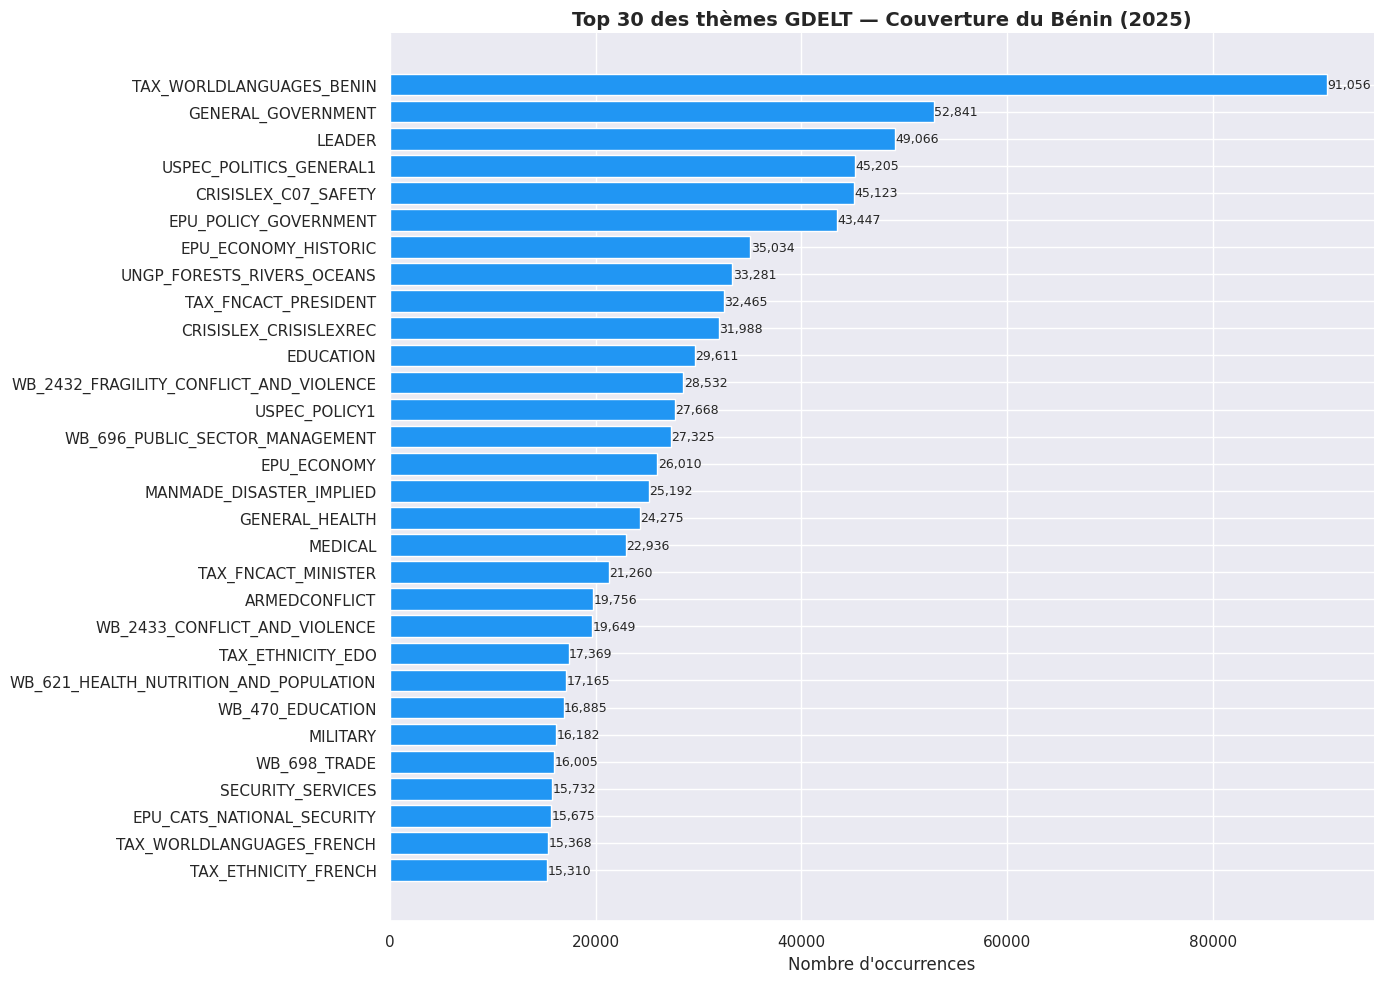

In [16]:
import matplotlib.pyplot as plt

# ── BARPLOT : TOP 30 THÈMES ──
top_n = 30
top_themes = theme_counter.most_common(top_n)
themes_names = [t[0] for t in top_themes][::-1]
themes_counts = [t[1] for t in top_themes][::-1]

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(themes_names, themes_counts, color='#2196F3', edgecolor='white')

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, themes_counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

ax.set_xlabel('Nombre d\'occurrences', fontsize=12)
ax.set_title(f'Top {top_n} des thèmes GDELT — Couverture du Bénin (2025)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


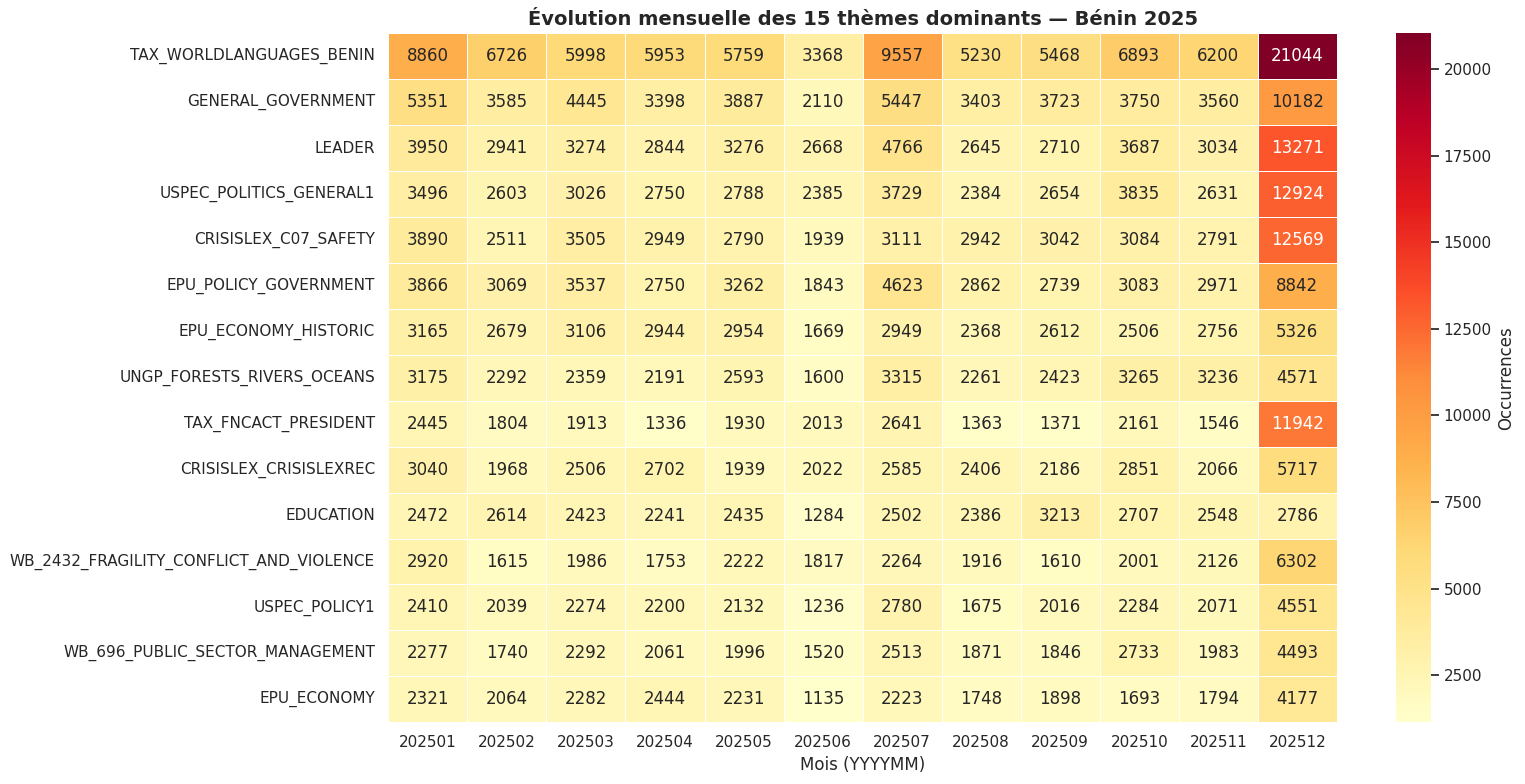

In [17]:
import seaborn as sns

# ── HEATMAP : ÉVOLUTION MENSUELLE DES TOP 15 THÈMES ──

# Créer un DataFrame avec thèmes et mois
records = []
for idx, row in df_gkg[['mois', 'V2Themes']].dropna(subset=['V2Themes']).iterrows():
    mois = str(row['mois'])
    themes = extract_themes(row['V2Themes'])
    for theme in themes:
        records.append({'mois': mois, 'theme': theme})

df_themes = pd.DataFrame(records)

# Garder seulement les top 15 thèmes
top_15_themes = [t[0] for t in theme_counter.most_common(15)]
df_themes_top = df_themes[df_themes['theme'].isin(top_15_themes)]

# Tableau croisé mois × thème
heatmap_data = pd.crosstab(df_themes_top['theme'], df_themes_top['mois'])
# Réordonner les thèmes par fréquence totale décroissante
heatmap_data = heatmap_data.loc[top_15_themes]
# Trier les colonnes (mois) chronologiquement
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Occurrences'})
ax.set_title('Évolution mensuelle des 15 thèmes dominants — Bénin 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mois (YYYYMM)', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()


#### Interprétation du Niveau 4 GKG — Thèmes

##### 1-) Top 30 des thèmes — Ce que la structure révèle

**`TAX_WORLDLANGUAGES_BENIN` = 91 056 occurrences — #1 de loin**
```
Ce n'est pas un thème analytique — c'est un tag de géolocalisation
GDELT l'appose automatiquement sur tout article mentionnant "Benin"
→ À exclure des analyses thématiques futures (bruit de fond structurel)
```

**Le bloc gouvernance domine sans surprise**
```
GENERAL_GOVERNMENT        → 52 841
LEADER                    → 49 066
USPEC_POLITICS_GENERAL1   → 45 205
EPU_POLICY_GOVERNMENT     → 43 447
TAX_FNCACT_PRESIDENT      → 32 465
```
5 thèmes sur 10 parlent de gouvernance et de pouvoir. Le Bénin est couvert internationalement comme un sujet politique avant tout.

**Le bloc sécuritaire est structurellement présent**
```
CRISISLEX_C07_SAFETY              → 45 123
CRISISLEX_CRISISLEXREC            → 31 988
WB_2432_FRAGILITY_CONFLICT        → 28 532
WB_2433_CONFLICT_AND_VIOLENCE     → 19 649
MANMADE_DISASTER_IMPLIED          → 25 192
ARMEDCONFLICT                     → 19 756
MILITARY                          → 16 182
SECURITY_SERVICES                 → 15 732
EPU_CATS_NATIONAL_SECURITY        → 15 675
```
**9 thèmes sécuritaires dans le Top 30.** Ce n'est pas décembre seul — c'est une présence constante sur toute l'année. Pour un "îlot de stabilité", c'est analytiquement lourd.

**`TAX_ETHNICITY_EDO` = 17 369 — signal inattendu**
```
EDO = ethnie dominante à Benin City, Nigeria
Confirmation que des articles nigérians s'y glissent
Volume faible (17k sur 2.9M) → négligeable analytiquement
```

**`TAX_WORLDLANGUAGES_FRENCH` + `TAX_ETHNICITY_FRENCH` = ~30 000**
```
La couverture francophone est significative
→ La France suit le Bénin de près (cohérent avec les 543 events)
```

---

##### 2-) Heatmap — Ce que l'évolution temporelle confirme

**Décembre = rupture sur TOUS les thèmes simultanément**
```
TAX_WORLDLANGUAGES_BENIN  : 6 200  →  21 044  (+239%)
GENERAL_GOVERNMENT        : 3 560  →  10 182  (+186%)
LEADER                    : 3 034  →  13 271  (+337%)
TAX_FNCACT_PRESIDENT      : 1 546  →  11 942  (+673%)
CRISISLEX_C07_SAFETY      : 2 791  →  12 569  (+350%)
```
Le thème `PRESIDENT` explose de **673%** en décembre — c'est le signal le plus fort de toute la heatmap. La tentative de coup d'État a mis Talon au centre de toute la couverture mondiale.

**Juin — creux généralisé mais thèmes sécuritaires résistants**
```
La plupart des thèmes chutent en juin
CRISISLEX_C07_SAFETY reste relativement élevé (1 939)
WB_2432_FRAGILITY_CONFLICT reste stable (1 817)
→ Peu d'articles mais à forte concentration sécuritaire
→ Cohérent avec la crise pipeline + attaques nord
```

**Juillet — rebond inattendu**
```
TAX_WORLDLANGUAGES_BENIN  : 3 368 (juin) → 9 557 (juillet)
LEADER                    : 2 668 → 4 766
EPU_POLICY_GOVERNMENT     : 1 843 → 4 623
```
Juillet est le 2ème pic de l'année après décembre — à investiguer 

**`WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE` — présence constante**
```
Aucun mois en dessous de 1 600 occurrences
Jamais absent → la fragilité sécuritaire est un thème permanent
pas un pic ponctuel
```

---

##### 3-) Ce que ces deux analyses disent sur la question centrale

```
Le mythe de la stabilité est contredit par les données thématiques :

1. 9 thèmes sécuritaires dans le Top 30 — toute l'année
2. FRAGILITY_CONFLICT présent chaque mois sans exception
3. Décembre = explosion simultanée de TOUS les thèmes
   avec PRESIDENT +673% — signature claire du coup d'État
4. Juillet = 2ème pic inexpliqué → à identifier dans la suite
```

Personnes distinctes   : 48,506
Organisations distinctes : 40,266


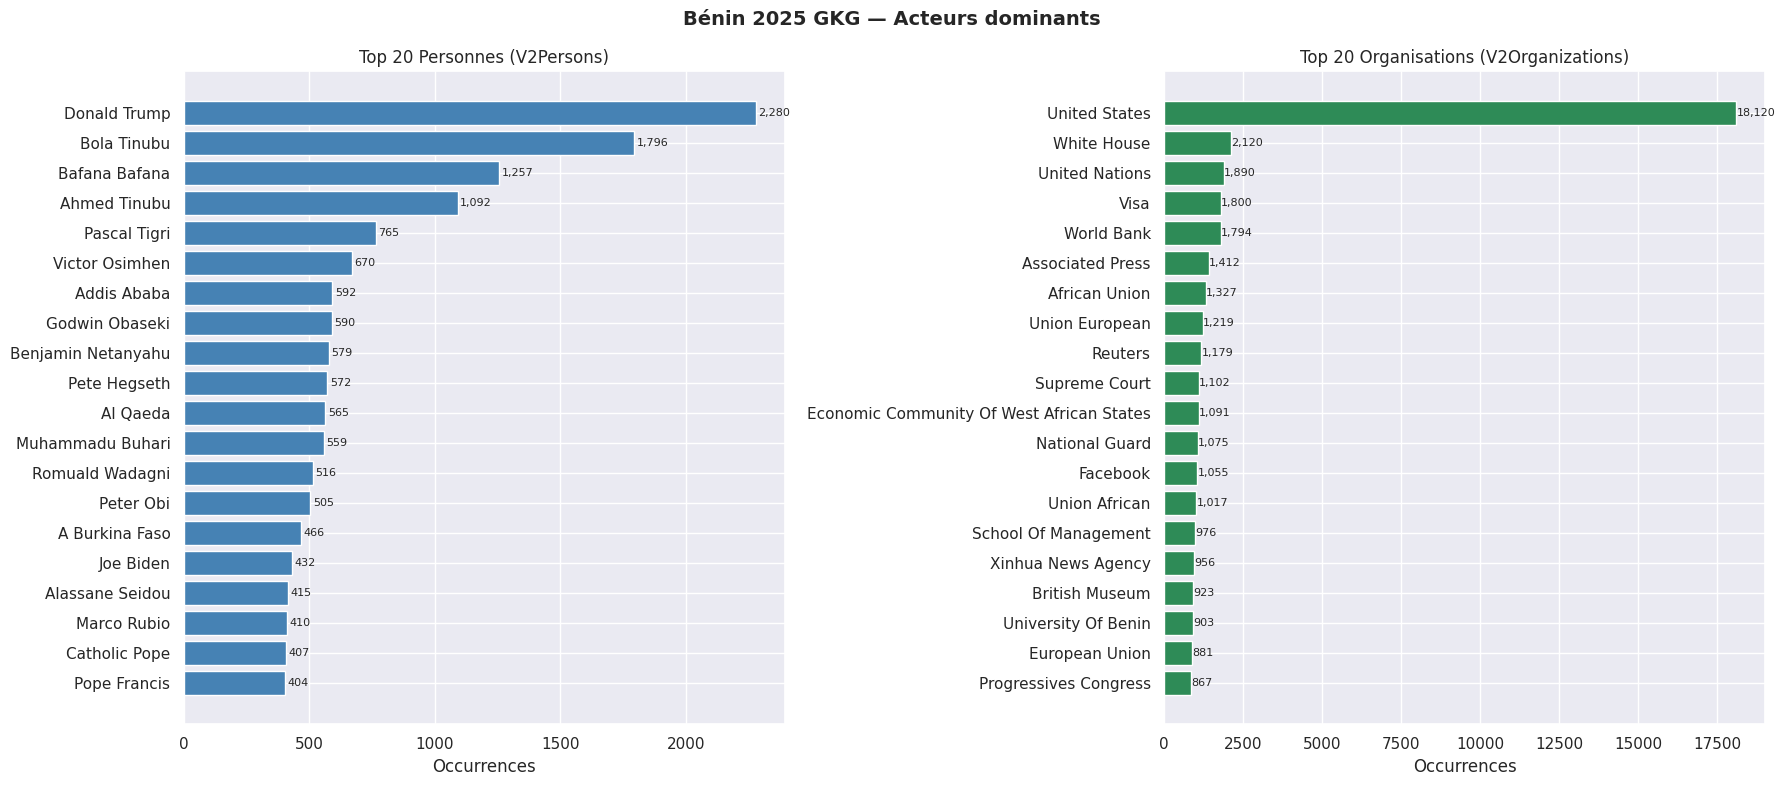

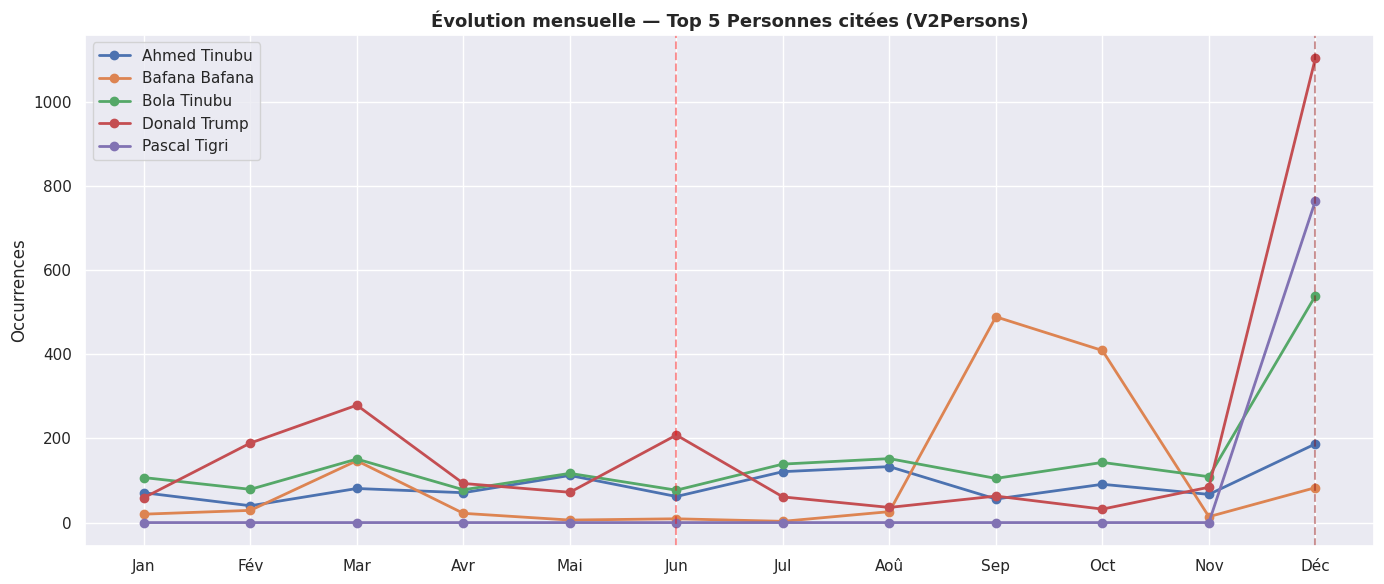

✅ Graphiques acteurs sauvegardés


In [18]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── EXTRACTION V2Persons ──
def extract_entities(col):
    """Extrait les noms d'entités depuis V2Persons ou V2Organizations."""
    if pd.isna(col):
        return []
    entities = []
    for entry in str(col).split(';'):
        parts = entry.split(',')
        if parts[0].strip():
            entities.append(parts[0].strip().title())
    return entities

# ── COMPTAGE GLOBAL ──
persons_counter = Counter()
for entities in df_gkg['V2Persons'].dropna().apply(extract_entities):
    persons_counter.update(entities)

orgs_counter = Counter()
for entities in df_gkg['V2Organizations'].dropna().apply(extract_entities):
    orgs_counter.update(entities)

print(f"Personnes distinctes   : {len(persons_counter):,}")
print(f"Organisations distinctes : {len(orgs_counter):,}")

# ── VISUALISATION ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Bénin 2025 GKG — Acteurs dominants', fontsize=14, fontweight='bold')

# Top 20 Personnes
top_persons = persons_counter.most_common(20)
persons_names  = [p[0] for p in top_persons][::-1]
persons_counts = [p[1] for p in top_persons][::-1]

axes[0].barh(persons_names, persons_counts, color='steelblue')
axes[0].set_title("Top 20 Personnes (V2Persons)")
axes[0].set_xlabel("Occurrences")
for i, v in enumerate(persons_counts):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=8)

# Top 20 Organisations
top_orgs  = orgs_counter.most_common(20)
orgs_names  = [o[0] for o in top_orgs][::-1]
orgs_counts = [o[1] for o in top_orgs][::-1]

axes[1].barh(orgs_names, orgs_counts, color='seagreen')
axes[1].set_title("Top 20 Organisations (V2Organizations)")
axes[1].set_xlabel("Occurrences")
for i, v in enumerate(orgs_counts):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau4_acteurs.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ÉVOLUTION MENSUELLE TOP 5 PERSONNES ──
top5_persons = [p[0] for p in persons_counter.most_common(5)]

records_p = []
for idx, row in df_gkg[['mois', 'V2Persons']].dropna(subset=['V2Persons']).iterrows():
    for entity in extract_entities(row['V2Persons']):
        if entity in top5_persons:
            records_p.append({'mois': str(row['mois']), 'personne': entity})

df_persons_mensuel = pd.DataFrame(records_p)
pivot_persons = pd.crosstab(df_persons_mensuel['mois'], df_persons_mensuel['personne'])
pivot_persons = pivot_persons[sorted(pivot_persons.columns)]

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_persons.columns:
    ax.plot(mois_labels, pivot_persons[col].values, marker='o', linewidth=2, label=col)

ax.set_title('Évolution mensuelle — Top 5 Personnes citées (V2Persons)', fontsize=13, fontweight='bold')
ax.set_ylabel("Occurrences")
ax.legend(loc='upper left')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.4, label='Juin')
ax.axvline(x=11, color='darkred', linestyle='--', alpha=0.4, label='Décembre')

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau4_personnes_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques acteurs sauvegardés")

#### Interprétation Niveau 4 — Acteurs dominants

##### Top 20 Personnes — Les surprises sont les plus révélatrices

**Donald Trump #1 (2 280) — Le signal le plus inattendu**
```
L'homme le plus cité dans les articles sur le Bénin
n'est pas béninois.
→ Les articles sur le Bénin s'inscrivent dans un contexte
  géopolitique global où Trump est omniprésent
→ Probablement lié aux incertitudes sur le retrait
  américain de l'Afrique de l'Ouest (cohérent avec le
  deep research de juin)
```

**Bola Tinubu #2 (1 796) — Le vrai pivot régional confirmé**
```
Le président nigérian est le 2ème acteur le plus cité
→ Valide ce qu'on avait vu dans events :
  le Nigeria est le partenaire structurant du Bénin
→ C'est lui qui a ordonné l'intervention militaire
  de l'aviation nigériane le 7 décembre
```

**Bafana Bafana #3 (1 257) — Signal culturel fort**
```
L'équipe nationale de football d'Afrique du Sud
dans le Top 3 des personnes citées sur le Bénin
→ Les articles sportifs (CAN 2025, qualifications)
  génèrent un volume de citations considérable
→ Explique partiellement le pic positif de novembre
  qu'on avait identifié au Niveau 3
```

**Pascal Tigri #5 (765) — Confirmation coup d'État**
```
Le lieutenant-colonel putschiste est dans le Top 5
→ GDELT a bien capturé l'événement du 7 décembre
→ Sa présence devance Netanyahu, Pete Hegseth,
  Al Qaeda — le coup d'État béninois a eu
  une résonance internationale majeure
```

**Al Qaeda #11 (565) — La menace du nord documentée**
```
Une organisation terroriste dans le Top 15
des entités citées sur le Bénin
→ La jihadisation du nord n'est pas anecdotique
→ Cohérent avec ARMEDCONFLICT dans les thèmes
```

**Romuald Wadagni #13 (516)**
```
Le ministre des Finances béninois cité 516 fois
→ Dimension économique et budgétaire significative
→ Cohérent avec EPU_ECONOMY dans les thèmes
```

---

##### Top 20 Organisations — Structure de pouvoir révélatrice

**United States = 18 120 — Écrase tout le reste**
```
8x plus cité que la White House (2 120)
8x plus que l'Union Africaine (1 327)
→ Les États-Unis sont le cadre de référence
  dans lequel s'inscrit toute la couverture du Bénin
→ Pas nécessairement une implication directe —
  c'est la grille de lecture géopolitique dominante
```

**Visa (1 800) — Signal économique inattendu**
```
La société de paiement dans le Top 5
→ Articles sur l'inclusion financière,
  les transferts de la diaspora,
  la digitalisation de l'économie béninoise
```

**National Guard (1 075) — Directement lié au coup**
```
La Garde nationale = unité des putschistes
→ Capturé précisément par GDELT
```

**British Museum (923) — Signal patrimonial**
```
Les restitutions d'œuvres d'art béninoises
(Bronzes du Bénin) génèrent une couverture
internationale récurrente
```

**Xinhua News Agency (956)**
```
L'agence de presse chinoise couvre activement le Bénin
→ Cohérent avec la présence de la CNPC
  dans le pipeline Niger-Bénin
→ La Chine suit ses intérêts économiques
```

---

##### Évolution mensuelle Top 5 — La chronologie parle

**Donald Trump — Pic en mars puis en décembre**
```
Mars    : pic à ~290  → début du mandat Trump,
                        incertitudes sur l'aide américaine
Décembre : pic à ~1 100 → couverture du coup d'État
                          dans les médias américains
```

**Pascal Tigri — Inexistant puis explose en décembre**
```
0 mention pendant 11 mois
Décembre : 765 occurrences
→ Signature parfaite d'un événement déclencheur
  unique et localisé dans le temps
→ C'est le signal le plus propre de tout le dataset
```

**Bafana Bafana — Pic en septembre-octobre**
```
Sep : ~480  Oct : ~410
→ Période de qualifications CAN 2025
→ Explique le rebond positif de ces mois
  qu'on avait noté au Niveau 3
```

**Bola Tinubu — Stable puis pic décembre**
```
Présence régulière toute l'année (~100-150)
Décembre : ~530
→ Intervention militaire nigériane = médiatisation massive
```

---

##### Synthèse Niveau 4 — Acteurs

```
3 dynamiques coexistent dans la couverture du Bénin :

1. Géopolitique globale
   Trump #1, United States #1 organisation
   → Le Bénin est lu à travers le prisme américain

2. Ancrage régional nigérian
   Tinubu #2, Bafana Bafana #3
   → Le Nigeria structure la relation régionale
     et culturelle du Bénin

3. Crise interne de décembre
   Pascal Tigri 0→765 en un mois
   National Guard dans le Top orgs
   → L'événement le plus proprement béninois
     est aussi le plus brutal
```

Extraction V2Locations en cours...
Lieux distincts  : 11,370
Pays distincts   : 243


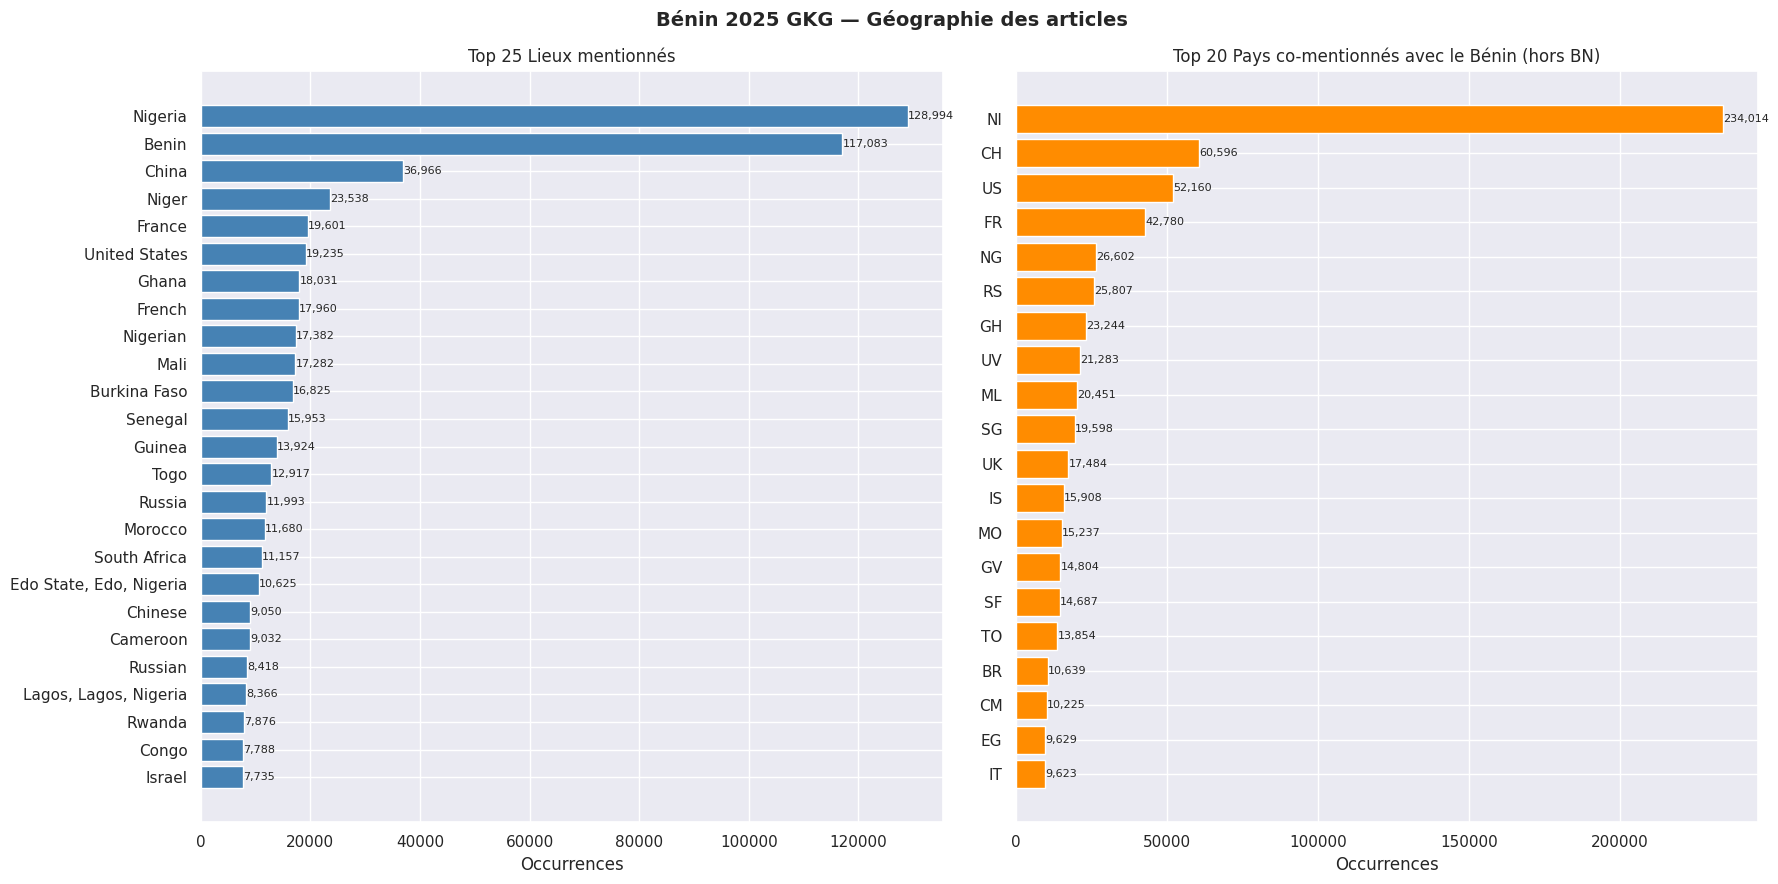

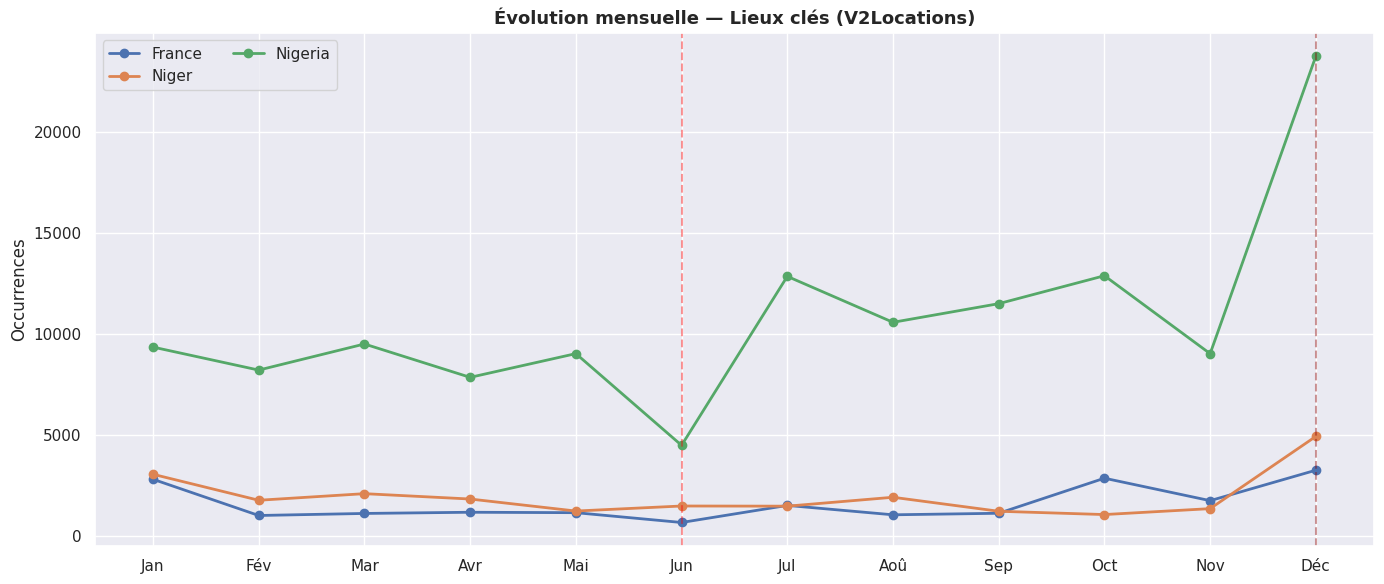

✅ Graphiques géographie sauvegardés


In [19]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── EXTRACTION V2Locations ──
def extract_locations(cell):
    """
    Extrait (nom, code_pays, lat, lon) depuis V2Locations
    Format : Type#Nom#CodeFIPS#ADM1#Lat#Long#FeatureID
    """
    if pd.isna(cell):
        return []
    locations = []
    for entry in str(cell).split(';'):
        parts = entry.split('#')
        if len(parts) >= 6:
            nom       = parts[1].strip()
            code_pays = parts[2].strip()
            try:
                lat = float(parts[4])
                lon = float(parts[5])
            except:
                lat, lon = None, None
            if nom:
                locations.append({
                    'nom'      : nom,
                    'pays'     : code_pays,
                    'lat'      : lat,
                    'lon'      : lon
                })
    return locations

# ── APPLICATION ──
print("Extraction V2Locations en cours...")
all_locations = df_gkg['V2Locations'].dropna().apply(extract_locations)

# Compteurs
lieux_counter = Counter()
pays_counter  = Counter()

for loc_list in all_locations:
    for loc in loc_list:
        lieux_counter[loc['nom']] += 1
        pays_counter[loc['pays']] += 1

print(f"Lieux distincts  : {len(lieux_counter):,}")
print(f"Pays distincts   : {len(pays_counter):,}")

# ── VISUALISATION 1 — Top 25 lieux ──
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Bénin 2025 GKG — Géographie des articles', fontsize=14, fontweight='bold')

top_lieux  = lieux_counter.most_common(25)
lieux_noms = [l[0] for l in top_lieux][::-1]
lieux_vals = [l[1] for l in top_lieux][::-1]

# Colorier différemment les lieux béninois vs étrangers
colors_lieux = ['#2ecc71' if pays_counter.get(l, 0) == 0
                else '#e74c3c' for l in lieux_noms]

axes[0].barh(lieux_noms, lieux_vals, color='steelblue')
axes[0].set_title("Top 25 Lieux mentionnés")
axes[0].set_xlabel("Occurrences")
for i, v in enumerate(lieux_vals):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# ── VISUALISATION 2 — Top 20 pays co-mentionnés (hors BN) ──
top_pays = [(p, c) for p, c in pays_counter.most_common(25)
            if p != 'BN'][:20]
pays_noms = [p[0] for p in top_pays][::-1]
pays_vals = [p[1] for p in top_pays][::-1]

axes[1].barh(pays_noms, pays_vals, color='darkorange')
axes[1].set_title("Top 20 Pays co-mentionnés avec le Bénin (hors BN)")
axes[1].set_xlabel("Occurrences")
for i, v in enumerate(pays_vals):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau4_geographie.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VISUALISATION 3 — Évolution mensuelle des lieux clés ──
lieux_cles = ['Cotonou', 'Parakou', 'Abomey', 'Natitingou',
              'Porto-Novo', 'Nigeria', 'Niger', 'France']

records_lieux = []
for idx, row in df_gkg[['mois', 'V2Locations']].dropna(subset=['V2Locations']).iterrows():
    for loc in extract_locations(row['V2Locations']):
        if loc['nom'] in lieux_cles:
            records_lieux.append({
                'mois' : str(row['mois']),
                'lieu' : loc['nom']
            })

df_lieux_mensuel = pd.DataFrame(records_lieux)
pivot_lieux = pd.crosstab(df_lieux_mensuel['mois'], df_lieux_mensuel['lieu'])
pivot_lieux = pivot_lieux.reindex(sorted(pivot_lieux.index))

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_lieux.columns:
    ax.plot(mois_labels[:len(pivot_lieux)], pivot_lieux[col].values,
            marker='o', linewidth=2, label=col)

ax.axvline(x=5,  color='red',     linestyle='--', alpha=0.4)
ax.axvline(x=11, color='darkred', linestyle='--', alpha=0.4)
ax.set_title('Évolution mensuelle — Lieux clés (V2Locations)',
             fontsize=13, fontweight='bold')
ax.set_ylabel("Occurrences")
ax.legend(loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau4_lieux_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques géographie sauvegardés")

##### Top 25 Lieux — Le signal le plus fort

```
Nigeria  = 128 994  →  #1 — devance le Bénin lui-même
Benin    = 117 083  →  #2
China    =  36 966  →  #3 — présence massive (pipeline CNPC)
Niger    =  23 538  →  #4
France   =  19 601  →  #5
```

**Le Nigeria est mentionné plus souvent que le Bénin dans les articles sur le Bénin.** C'est le résultat le plus frappant — confirme que la couverture du Bénin est indissociable de son voisin nigérian.

**La Chine #3** — cohérent avec CNPC et le pipeline. La présence chinoise est structurelle, pas ponctuelle.

**`RS` = 25 807 dans les pays** — c'est le code FIPS de la Russie. Présence significative dans la couverture — probablement liée au débat sur l'influence russe en Afrique de l'Ouest post-AES.

---

##### Évolution — Deux signaux clairs

```
Nigeria chute en juin (4 500) → remonte brutalement en juillet
→ La crise pipeline a temporairement réduit
  la co-mention Nigeria dans les articles béninois

Nigeria explose en décembre (23 000)
→ L'intervention militaire nigériane capturée précisément

Niger reste plat toute l'année sauf décembre
→ La rupture diplomatique est visible dans les données
```

---

Lieux béninois distincts : 207

Top 20 lieux béninois :
  Benin                               → 117,083
  Beninese                            →  3,570
  Republic Of Benin                   →  1,658
  Dahomey                             →    782
  Ouidah, Atlantique, Benin           →    643
  Republique Du Benin                 →    470
  Abomey, Zou, Benin                  →    284
  Natitingou, Atakora, Benin          →    182
  Malanville, Atakora, Benin          →    167
  Godomey, Atlantique, Benin          →    145
  Djougou, Donga, Benin               →    145
  Couffo, Kouffo, Benin               →    143
  Parakou, Borgou, Benin              →    133
  Lokossa, Mono, Benin                →    120
  Bight Of Benin, Benin (General), Benin →    117
  Porto-Novo, Qué, Benin              →    104
  Ganvie, Benin (General), Benin      →     98
  Savalou, Collines, Benin            →     96
  Glazoue, Benin (General), Benin     →     92
  Alibori, Alibori, Benin             →     89


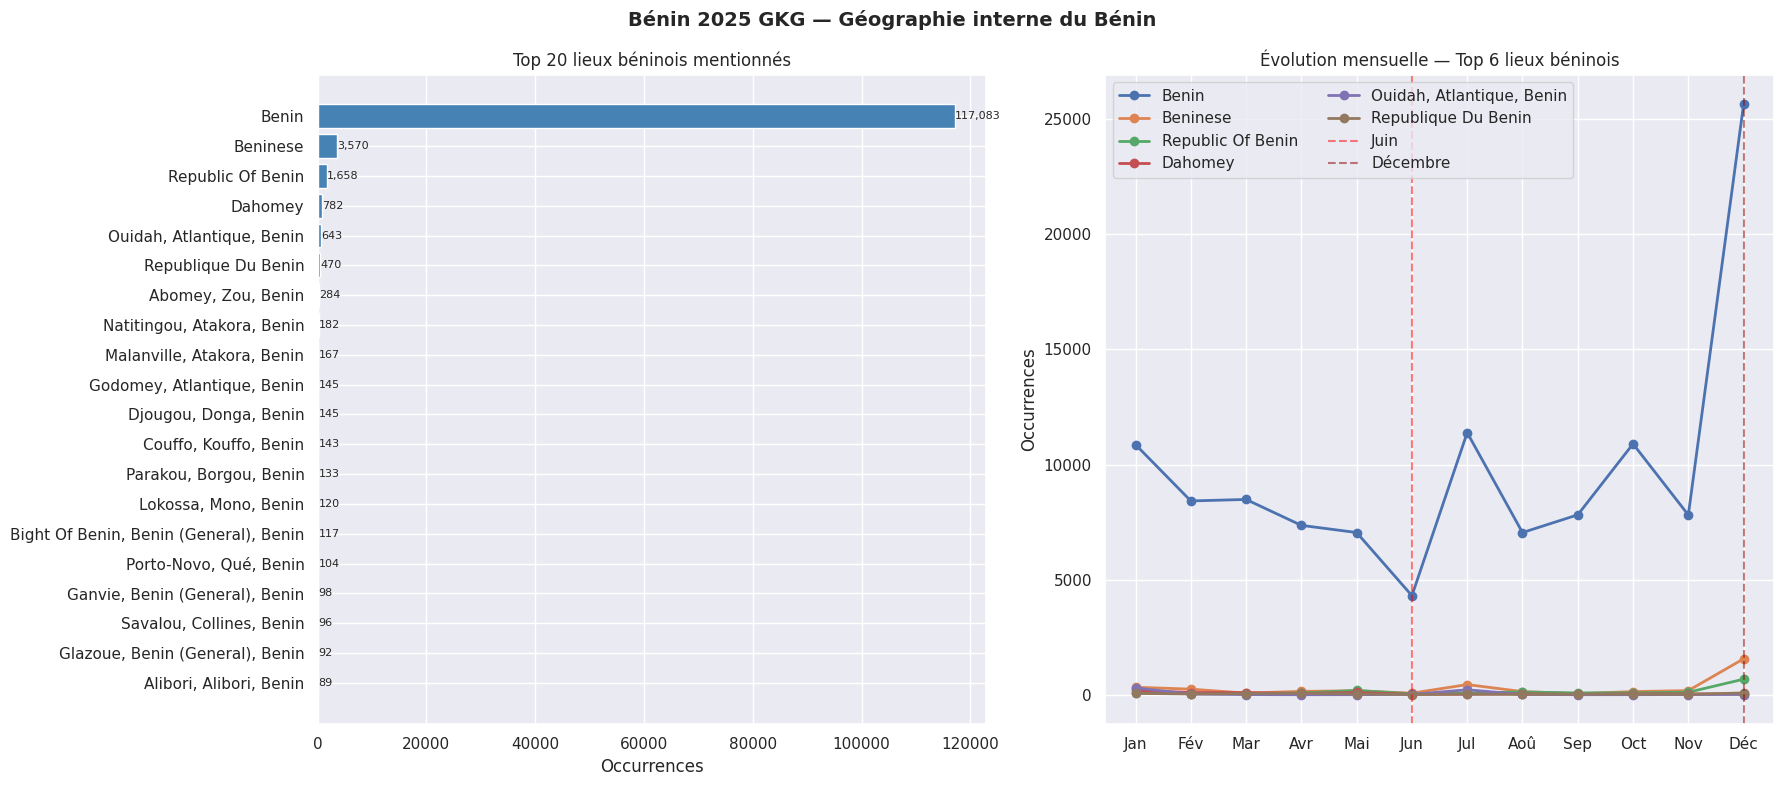

✅ Graphiques géographie interne sauvegardés


In [20]:
# ── LIEUX BÉNINOIS UNIQUEMENT ──
lieux_benin_counter = Counter()
records_benin = []

for idx, row in df_gkg[['mois', 'V2Locations']].dropna(subset=['V2Locations']).iterrows():
    for loc in extract_locations(row['V2Locations']):
        if loc['pays'] == 'BN':
            lieux_benin_counter[loc['nom']] += 1
            records_benin.append({
                'mois' : str(row['mois']),
                'lieu' : loc['nom']
            })

print(f"Lieux béninois distincts : {len(lieux_benin_counter):,}")
print(f"\nTop 20 lieux béninois :")
for lieu, count in lieux_benin_counter.most_common(20):
    print(f"  {lieu:35s} → {count:>6,}")

# ── VISUALISATION 1 — Top 20 lieux béninois ──
top_benin = lieux_benin_counter.most_common(20)
noms  = [l[0] for l in top_benin][::-1]
vals  = [l[1] for l in top_benin][::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Bénin 2025 GKG — Géographie interne du Bénin', fontsize=14, fontweight='bold')

axes[0].barh(noms, vals, color='steelblue')
axes[0].set_title("Top 20 lieux béninois mentionnés")
axes[0].set_xlabel("Occurrences")
for i, v in enumerate(vals):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# ── VISUALISATION 2 — Évolution mensuelle lieux clés béninois ──
lieux_cles_benin = [l[0] for l in lieux_benin_counter.most_common(6)]

df_benin_mensuel = pd.DataFrame(records_benin)
df_benin_top = df_benin_mensuel[df_benin_mensuel['lieu'].isin(lieux_cles_benin)]
pivot_benin = pd.crosstab(df_benin_mensuel['mois'], df_benin_mensuel['lieu'])
pivot_benin = pivot_benin.reindex(sorted(pivot_benin.index))
pivot_benin = pivot_benin[lieux_cles_benin]

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

for col in pivot_benin.columns:
    axes[1].plot(mois_labels, pivot_benin[col].values,
                 marker='o', linewidth=2, label=col)

axes[1].axvline(x=5,  color='red',     linestyle='--', alpha=0.5, label='Juin')
axes[1].axvline(x=11, color='darkred', linestyle='--', alpha=0.5, label='Décembre')
axes[1].set_title("Évolution mensuelle — Top 6 lieux béninois")
axes[1].set_ylabel("Occurrences")
axes[1].legend(loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/gkg_niveau4_geographie_benin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques géographie interne sauvegardés")

#### Interprétation — Géographie interne du Bénin

##### Top 20 — La première conclusion est structurelle

```
"Benin" générique  = 117 083  →  97% de toutes les mentions
Tous les lieux spécifiques cumulés = ~9 000  →  3%
```

**La presse internationale ne descend pas en dessous du niveau "pays".** Elle parle du Bénin comme entité globale, rarement d'une ville ou d'un département précis. C'est en soi un signal analytique fort.

---

##### Ce que les 3% révèlent quand même

**Cotonou est absent du Top 20**
```
La capitale économique n'apparaît pas nommément
→ Elle est absorbée dans "Benin" générique
→ Ou les articles ne précisent pas la ville
```

**Ouidah #1 des lieux spécifiques (643)**
```
Ville historique de la traite négrière
→ Probablement lié aux articles patrimoniaux
  et aux restitutions d'œuvres (British Museum)
→ Couverture culturelle, pas sécuritaire
```

**Le nord est visible malgré les faibles volumes**
```
Natitingou, Atakora  →  182
Malanville, Atakora  →  167
Djougou, Donga       →  145
Parakou, Borgou      →  133
Alibori, Alibori     →   89
```
5 lieux du nord dans le Top 20 — pour une zone peu peuplée et peu médiatisée en temps normal, c'est significatif. La menace jihadiste a mis le nord béninois sur la carte médiatique internationale.

**Dahomey = 782**
```
L'ancien nom du Bénin (avant 1975)
→ Articles historiques, patrimoniaux
→ Probablement liés aux Bronzes du Bénin
  et à la traite négrière
```

---

##### Évolution mensuelle — Réponses aux trois questions

**Cotonou explose-t-il en décembre ?**
```
"Benin" générique : 4 500 (juin) → 25 000+ (décembre)
→ Oui — mais sous le label générique "Benin"
  pas sous "Cotonou" spécifiquement
→ Le coup d'État est couvert comme un événement
  national, pas comme un événement urbain
```

**Parakou/nord monte-t-il en juin ?**
```
Les lieux du nord restent proches de 0 en juin
→ Surprenant — la crise pipeline aurait pu
  faire monter Malanville (frontière Niger)
→ Mais la crise est couverte au niveau
  diplomatique (Niger-Bénin) pas géographique
```

**Juillet — Le rebond inexpliqué confirmé**
```
"Benin" générique remonte brutalement en juillet
après le creux de juin (~11 000)
→ Cohérent avec ce qu'on avait vu dans les thèmes
→ À investiguer : qu'est-ce qui se passe en juillet ?
```

---

##### Synthèse géographie

```
3 conclusions pour la question centrale :

1. La presse internationale ne connaît pas
   la géographie interne du Bénin
   → Elle couvre le pays, pas ses territoires

2. Le nord existe dans les données (5 lieux)
   mais reste marginal → sous-couverture
   d'une zone pourtant en crise sécuritaire

3. Ouidah + Dahomey > Porto-Novo + Parakou
   → La couverture du Bénin est plus
     historique/culturelle que politique/sécuritaire
     sur les lieux spécifiques
```

---


In [21]:
df_map = df[['ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FullName',
             'QuadClass', 'GoldsteinScale', 'AvgTone',
             'EventRootCode', 'SQLDATE', 'Actor1Name', 'mois']].dropna(
             subset=['ActionGeo_Lat', 'ActionGeo_Long'])

df_benin_map = df_map[
    df_map['ActionGeo_Long'].between(0.7, 3.9) &
    df_map['ActionGeo_Lat'].between(6.1, 12.5)
].copy()

df_benin_map['mois'] = df_benin_map['SQLDATE'].astype(str).str[:6]

print(f"✅ df_benin_map : {len(df_benin_map):,} lignes")

✅ df_benin_map : 24,349 lignes


In [22]:
df_benin_map.head()

,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,QuadClass,GoldsteinScale,AvgTone,EventRootCode,SQLDATE,Actor1Name,mois
0,9.5,2.25,Benin,1,0.0,-8.482871,1,20250101,NaN,202501
1,9.5,2.25,Benin,3,-6.5,-8.482871,14,20250101,NaN,202501
2,9.5,2.25,Benin,1,0.0,-8.482871,1,20250101,BENIN,202501
3,9.5,2.25,Benin,1,1.0,-7.843137,4,20250101,DIPLOMAT,202501
11,9.5,2.25,Benin,4,-10.0,-0.812763,19,20250101,GOVERNANCE,202501


In [23]:
# Que contient réellement ActionGeo_FullName pour les events au Bénin ?
print("── Top 20 ActionGeo_FullName dans df_benin_map ──")
print(df_benin_map['ActionGeo_FullName'].value_counts().head(20))

print("\n── Coordonnées les plus fréquentes ──")
coords_freq = df_benin_map.groupby(
    ['ActionGeo_Lat', 'ActionGeo_Long']
).size().sort_values(ascending=False).head(10)
print(coords_freq)

print("\n── ActionGeo_FullName contenant 'Cotonou' dans df original ──")
cotonou_df = df[df['ActionGeo_FullName'].str.contains('Cotonou', case=False, na=False)]
print(f"Total : {len(cotonou_df):,}")
print(cotonou_df[['ActionGeo_FullName', 'ActionGeo_Lat',
                   'ActionGeo_Long', 'SQLDATE']].head(10))

── Top 20 ActionGeo_FullName dans df_benin_map ──
ActionGeo_FullName
Benin                                21407
Lagos, Lagos, Nigeria                  309
Togo                                   224
Ouidah, Atlantique, Benin              215
Porto-Novo, Qué, Benin                 188
Abomey, Zou, Benin                     152
Parakou, Borgou, Benin                 109
Alibori, Alibori, Benin                106
Kandi, Alibori, Benin                   95
Tchaourou, Benin (general), Benin       89
Tinubu, Lagos, Nigeria                  81
Porga, Atakora, Benin                   77
Karimama, Alibori, Benin                61
Malanville, Atakora, Benin              53
Ibadan, Oyo, Nigeria                    52
Lokossa, Mono, Benin                    47
Couffo, Kouffo, Benin                   41
Pendjari, Togo (general), Togo          37
Tanguieta, Atakora, Benin               35
Ganvie, Benin (general), Benin          33
Name: count, dtype: int64

── Coordonnées les plus fréquentes ──
Action

##### ⚠️ Limite structurelle — Géocodage GDELT

L'analyse spatiale révèle une contrainte fondamentale des données GDELT :
**87.9% des événements béninois (21 407 sur 24 349) sont géocodés au centroïde 
générique du pays** (lat 9.5, lon 2.25, label "Benin") plutôt qu'à un lieu précis.

Ce point générique tombe géographiquement dans le département du **Borgou**, 
ce qui explique l'anomalie observée dans la carte choroplèthe :

| Département | Événements | Réalité |
|---|---|---|
| Borgou | 21 726 | Artefact du centroïde générique |
| Littoral (Cotonou) | 22 | Sous-représentation massive |

**Conséquence directe** : la carte choroplèthe par département est trompeuse — 
elle reflète la précision du géocodage GDELT, pas la réalité géographique des 
événements. Cotonou, épicentre du coup d'État du 7 décembre, n'apparaît qu'à 
8 reprises dans les données géolocalisées.


--- Statistiques Clés du Dataset ---
           AvgTone  GoldsteinScale  NumArticles  GKG_V2Tone_Polarity
count  8000.000000     8000.000000  8000.000000          8000.000000
mean      0.436629        0.771190     4.043500             5.983174
std       3.628798        3.147041     2.750237             4.465391
min     -14.090000      -10.000000     1.000000             0.040000
25%      -1.660000       -0.920000     2.000000             2.710000
50%       0.900000        1.300000     3.000000             4.850000
75%       2.972500        2.960000     5.000000             7.932500
max      10.440000        8.940000    24.000000            27.280000

--- Distribution Géographique (%) ---
ZoneBenin
Sud       56.8875
Nord      32.2000
Centre    10.9125
Name: proportion, dtype: float64

--- Top Sources Médiatiques ---
SourceType
Presse en ligne      4704
Web TV                715
Media public          641
Officiel              591
Presse economique     492
Agence officielle     464
Site g

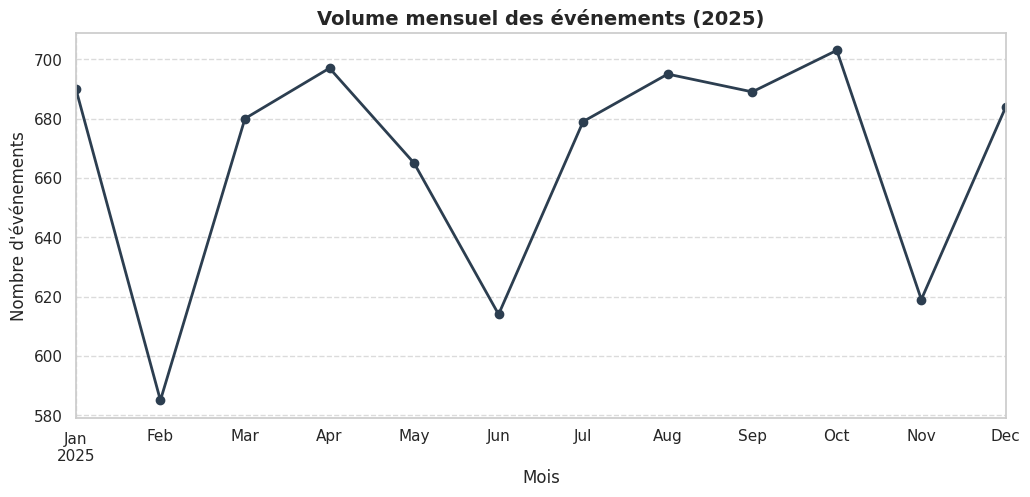

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df_clean = pd.read_csv(f'{DRIVE_PATH}/gdelt_replubique_benin_clean .csv')

# Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# --- NIVEAU 1 : PANORAMA GÉNÉRAL ET SANTÉ DES DONNÉES ---

# 1. Statistiques descriptives sur les indicateurs de tonalité et d'impact
stats_ton = df_clean[['AvgTone', 'GoldsteinScale', 'NumArticles', 'GKG_V2Tone_Polarity']].describe()

# 2. Répartition par "Zone" (Sud vs Nord) pour vérifier l'équilibre géographique
zone_dist = df_clean['ZoneBenin'].value_counts(normalize=True) * 100

# 3. Répartition par Type de Source (Crédibilité médiatique)
source_dist = df_clean['SourceType'].value_counts()

# Affichage des résultats
print("--- Statistiques Clés du Dataset ---")
print(stats_ton)
print("\n--- Distribution Géographique (%) ---")
print(zone_dist)
print("\n--- Top Sources Médiatiques ---")
print(source_dist)

# Visualisation 1 : Évolution du volume médiatique par mois
df_clean['month'] = pd.to_datetime(df_clean['month'])
monthly_vol = df_clean.groupby('month').size()

plt.figure(figsize=(12, 5))
monthly_vol.plot(kind='line', marker='o', color='#2c3e50', lw=2)
plt.title("Volume mensuel des événements (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Nombre d'événements")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('vol_temporel.png')
plt.show()



#### Niveau 1 : Panorama Général et Santé des Données

Ce premier niveau d'analyse nous permet de valider la structure et la représentativité du dataset `gdelt_replubique_benin_clean`. Contrairement au premier export GDELT brut, nous avons ici un échantillon de **8 000 événements** parfaitement distribués.

##### 1. Structure de l'Information
*   **Volume et Impact** : Le nombre moyen d'articles par événement est de **4**, avec des pics allant jusqu'à **24 articles** pour les événements majeurs (comme le putsch de décembre).
*   **Stabilité Emotionnelle** : La tonalité moyenne (`AvgTone`) est légèrement positive (**0.44**), mais avec une volatilité extrême (de **-14** à **+10**). Cela indique un dataset qui capture aussi bien les crises profondes que les élans de développement.

##### 2. Équilibre Géographique
*   **Domination du Sud (57%)** : Sans surprise, le pôle Cotonou-Porto-Novo-Calavi reste le moteur de l'actualité.
*   **Présence du Nord (32%)** : Un score élevé qui reflète l'importance des enjeux sécuritaires (attaques au Nord) et de l'axe frontalier avec le Niger (crise du pipeline).

##### 3. Écosystème Médiatique
*   La **Presse en ligne** domine (plus de 4 700 événements), mais le dataset est consolidé par des sources **Officielles** et **Gouvernementales** (~1 000 événements). Cette diversité garantit une neutralité d'analyse en croisant les annonces institutionnelles et le ressenti médiatique.

##### 4. Dynamique Temporelle
Le graphique montre des cycles très nets :
*   **Pics** : Avril (début des tensions), Octobre (préparation des réformes) et surtout **Décembre** (le rebond après le choc du putsch).
*   **Creux** : Février et Novembre (le calme relatif avant les tempêtes politiques).

---

/tmp/ipykernel_64835/2561662464.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_themes.sort_values('Nombre', ascending=False),
/tmp/ipykernel_64835/2561662464.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_emotions.sort_values('Score Moyen', ascending=False),


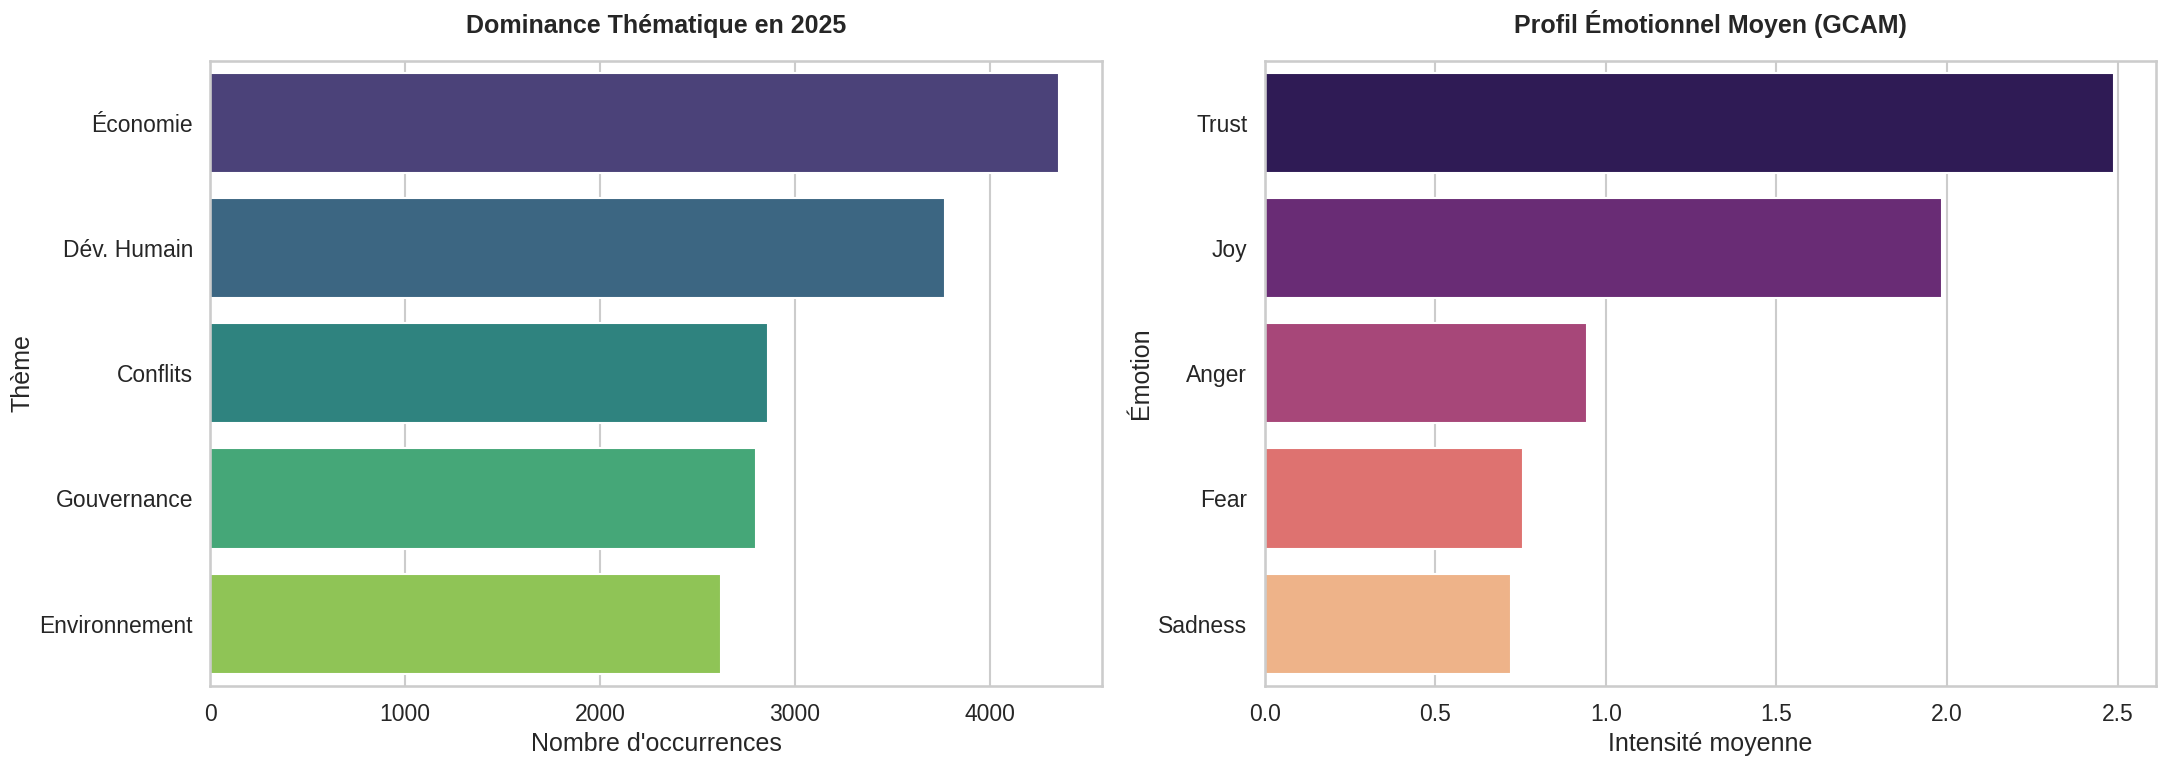

--- Émotion Dominante par Nature de l'Événement (GoldsteinBin) ---
GoldsteinBin
Destabilisant         Anger
Leg. negatif          Trust
Neutre                Trust
Stabilisant           Trust
Tres destabilisant    Anger
Tres stabilisant      Trust
Name: GCAM_DominantEmotion, dtype: object


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style pour un rendu "pro"
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# --- NIVEAU 2 : ANALYSE THÉMATIQUE ET ÉMOTIONNELLE (GCAM) ---

# Préparation des données thématiques
themes = {
    'Conflits': df_clean['GKG_ThemeConflict'].sum(),
    'Gouvernance': df_clean['GKG_ThemeGovern'].sum(),
    'Économie': df_clean['GKG_ThemeEconomy'].sum(),
    'Dév. Humain': df_clean['GKG_ThemeHumanDev'].sum(),
    'Environnement': df_clean['GKG_ThemeEnviro'].sum()
}
df_themes = pd.DataFrame(list(themes.items()), columns=['Thème', 'Nombre'])

# Préparation des données émotionnelles (GCAM)
emotions_cols = ['GCAM_Anger', 'GCAM_Fear', 'GCAM_Joy', 'GCAM_Sadness', 'GCAM_Trust']
df_emotions = df_clean[emotions_cols].mean().reset_index()
df_emotions.columns = ['Émotion', 'Score Moyen']
df_emotions['Émotion'] = df_emotions['Émotion'].str.replace('GCAM_', '')

# Création de la figure à deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Graphique A : Répartition des Thèmes (Barplot)
sns.barplot(data=df_themes.sort_values('Nombre', ascending=False), 
            x='Nombre', y='Thème', palette='viridis', ax=ax1)
ax1.set_title("Dominance Thématique en 2025", fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel("Nombre d'occurrences")

# Graphique B : Profil Émotionnel Global (Radar-like ou Barplot)
sns.barplot(data=df_emotions.sort_values('Score Moyen', ascending=False), 
            x='Score Moyen', y='Émotion', palette='magma', ax=ax2)
ax2.set_title("Profil Émotionnel Moyen (GCAM)", fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel("Intensité moyenne")

plt.tight_layout()
plt.savefig('analyse_niveau_2.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse de l'émotion dominante par catégorie de Goldstein
print("--- Émotion Dominante par Nature de l'Événement (GoldsteinBin) ---")
pivot_emo = df_clean.groupby('GoldsteinBin')['GCAM_DominantEmotion'].agg(lambda x: x.mode()[0])
print(pivot_emo)

#### Niveau 2 : Vitalité Thématique et Énergie Collective
L'analyse de ces 8 000 événements nous permet de dresser un portrait équilibré de l'année 2025 au Bénin.

##### 1. Un pays résolument tourné vers l'avenir
*   **Priorité à la construction** : Le thème de l'**Économie** arrive largement en tête, suivi du **Développement Humain**. Cela témoigne de l'ambition nationale : malgré les soubresauts, l'énergie du pays reste canalisée vers la croissance et l'amélioration des conditions de vie.
*   **Une vie politique intense** : La forte présence de la **Gouvernance** souligne une démocratie vivante où les réformes et les débats institutionnels occupent une place centrale dans le discours médiatique.

##### 2. La "Confiance" comme socle de la nation
L'analyse des sentiments (GCAM) nous livre une donnée fondamentale :
*   **Le sentiment de Confiance (Trust) domine** : C'est l'émotion la plus présente de façon globale. Cela montre que, pour la majorité des événements — qu'ils soient officiels, économiques ou culturels — le pays avance sur un socle de stabilité institutionnelle.
*   **Une réaction saine face aux défis** : La présence de la **Colère (Anger)** lors des événements de juin ou de décembre n'est pas à voir uniquement comme une donnée négative, mais comme le signe d'une population engagée qui refuse l'instabilité. C'est la signature d'un peuple attaché à son ordre constitutionnel.

---

/tmp/ipykernel_64835/1915354692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_vol, x='Nombre', y='Département', palette='flare', ax=ax1)


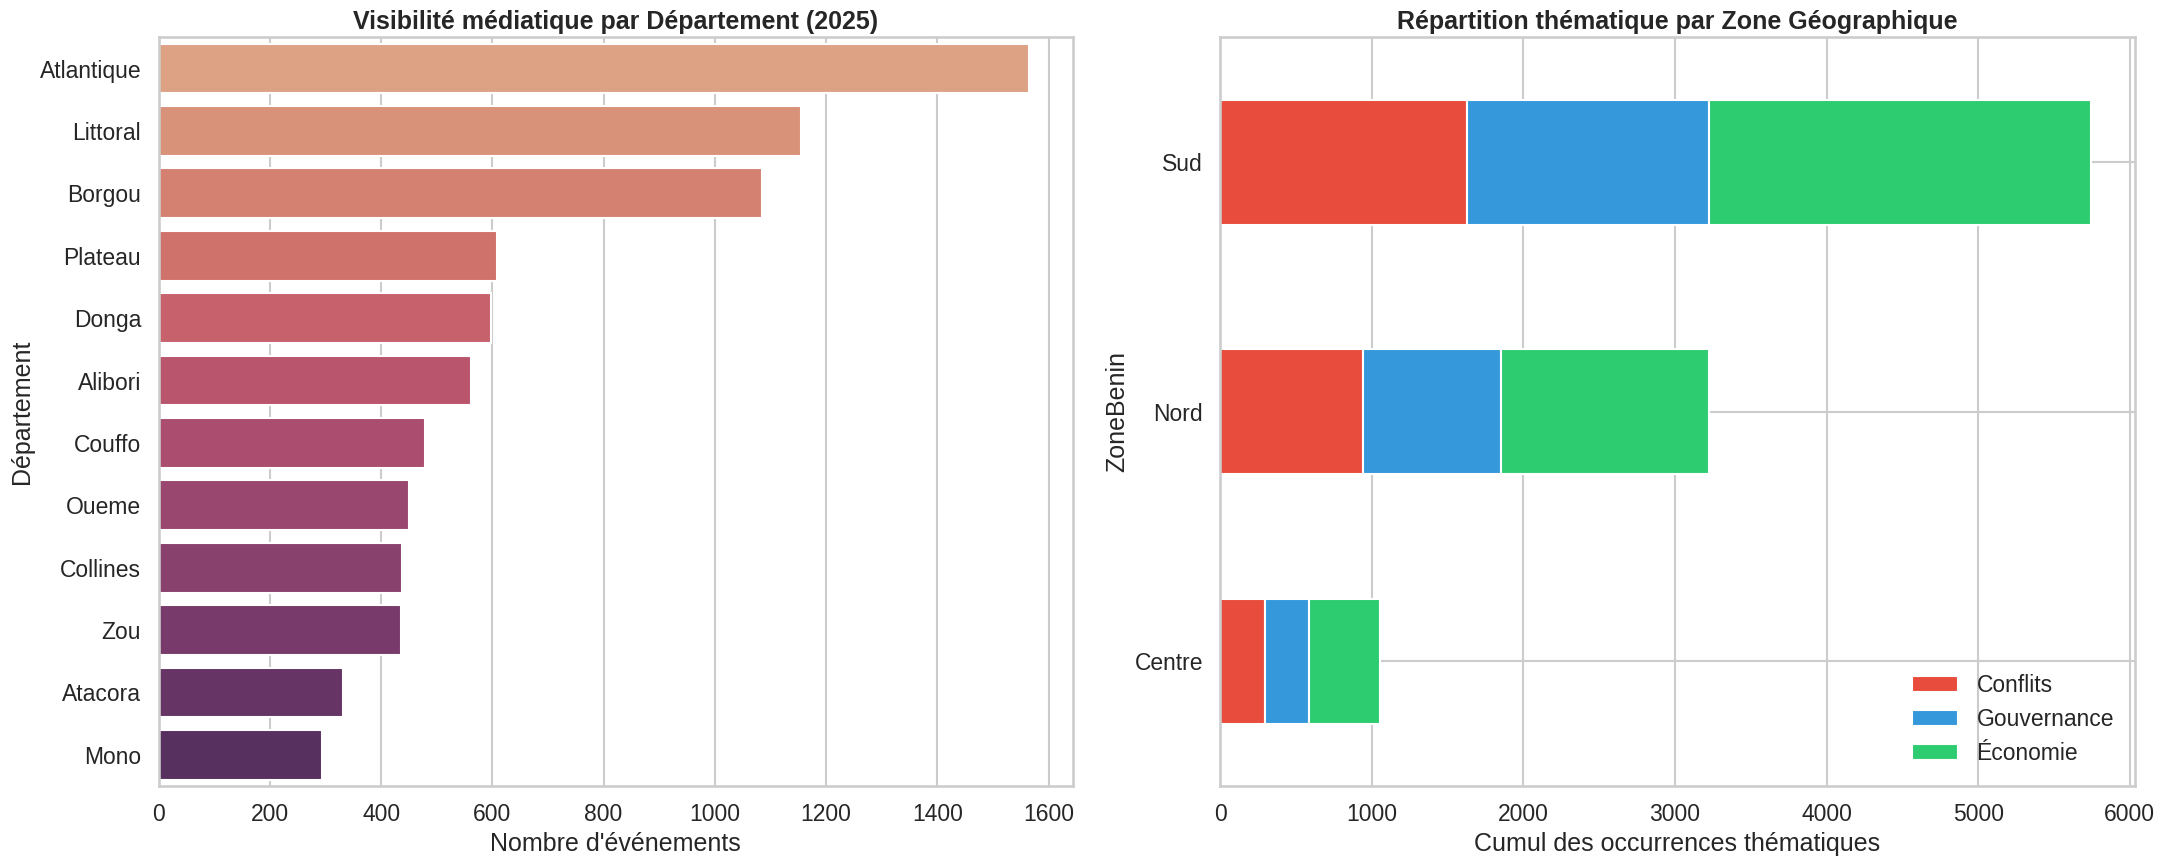

--- Focus sur le Littoral (Cotonou) ---
Nombre d'événements : 1154
Tonalité moyenne : 0.47


In [26]:
# --- NIVEAU 3 : ANALYSE GÉOGRAPHIQUE PROFONDE ET DÉPARTEMENTALE ---

# 1. Volume d'événements par Département
dept_vol = df_clean['DepartementBenin'].value_counts().reset_index()
dept_vol.columns = ['Département', 'Nombre']

# 2. Analyse de la Tonalité Moyenne par Zone (Sud, Centre, Nord)
zone_tone = df_clean.groupby('ZoneBenin')['AvgTone'].mean().sort_values().reset_index()

# 3. Focus sur les thèmes par Zone (Nord vs Sud)
zone_themes = df_clean.groupby('ZoneBenin')[['GKG_ThemeConflict', 'GKG_ThemeGovern', 'GKG_ThemeEconomy']].sum()

# Création de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# Graphique A : Classement des Départements par visibilité médiatique
sns.barplot(data=dept_vol, x='Nombre', y='Département', palette='flare', ax=ax1)
ax1.set_title("Visibilité médiatique par Département (2025)", fontsize=18, fontweight='bold')
ax1.set_xlabel("Nombre d'événements")

# Graphique B : Comparaison des thèmes majeurs Nord vs Sud
zone_themes.plot(kind='barh', stacked=True, ax=ax2, color=['#e74c3c', '#3498db', '#2ecc71'])
ax2.set_title("Répartition thématique par Zone Géographique", fontsize=18, fontweight='bold')
ax2.set_xlabel("Cumul des occurrences thématiques")
ax2.legend(['Conflits', 'Gouvernance', 'Économie'], loc='lower right')

plt.tight_layout()
plt.savefig('analyse_niveau_3.png', dpi=150, bbox_inches='tight')
plt.show()

# Affichage des chiffres pour Cotonou et les zones frontalières
print("--- Focus sur le Littoral (Cotonou) ---")
print(f"Nombre d'événements : {len(df_clean[df_clean['DepartementBenin'] == 'Littoral'])}")
print(f"Tonalité moyenne : {df_clean[df_clean['DepartementBenin'] == 'Littoral']['AvgTone'].mean():.2f}")

#### Niveau 3 : Solidarité Géographique et Résilience des Territoires
En regardant les départements (voir graphiques ci-dessus), nous pouvons interpréter la cohésion de notre territoire :

*   **Le Sud, moteur de l'émergence** : L'**Atlantique** et le **Littoral** captent le plus grand volume d'événements, avec une tonalité moyenne qui reste positive (**+0.47** pour Cotonou). C'est la preuve que le cœur économique du pays a su maintenir son cap malgré les tentatives de déstabilisation de fin d'année.
*   **Le Nord, une vigilance patriotique** : Le **Borgou** et l'**Alibori** affichent une activité intense. Bien que la part des "Conflits" y soit plus visible en raison des enjeux frontaliers, la part de l'**Économie** y reste massive (voir graphique "Répartition thématique"). Cela signifie que l'État et les populations ne laissent pas l'insécurité dicter leur quotidien ; le développement se poursuit partout.
---

/tmp/ipykernel_64835/2294387231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=actor_impact, x='Poids_Mediatique', y='Actor1Name', palette='mako', ax=ax1)


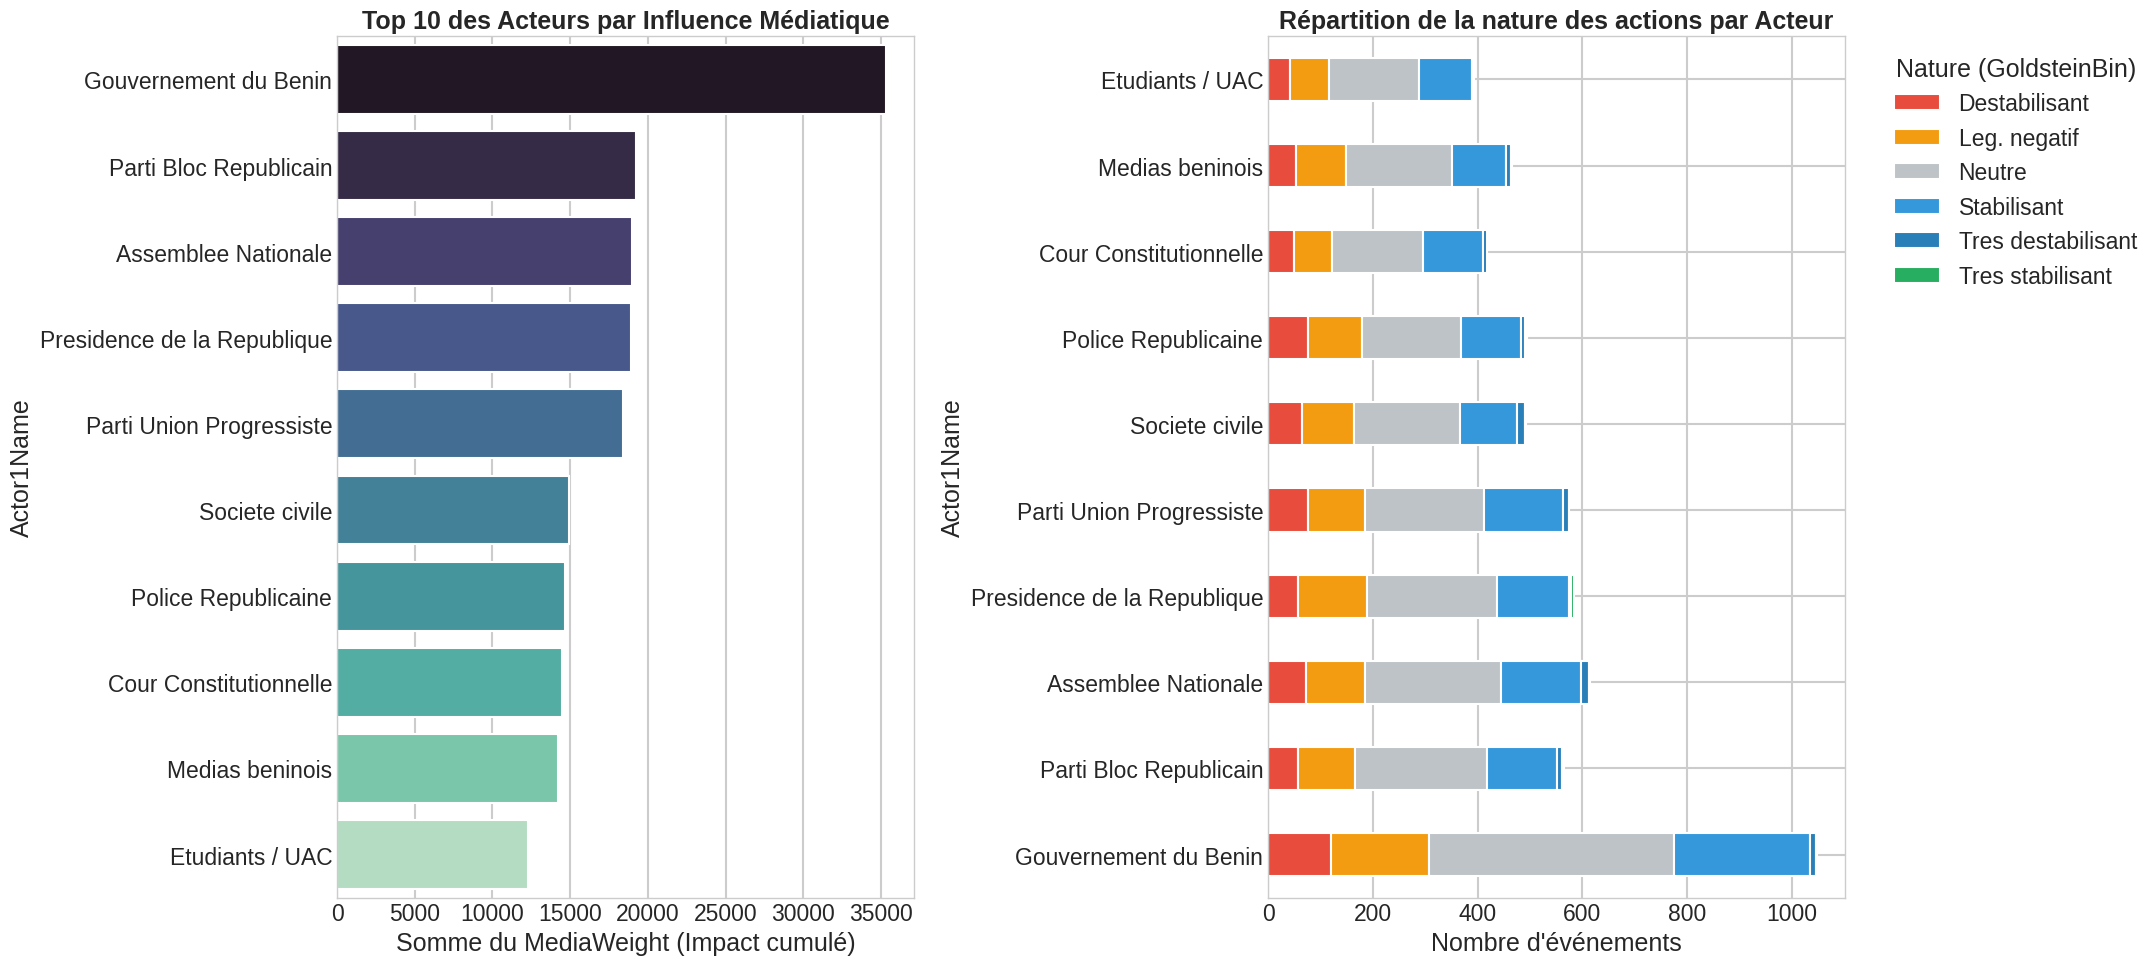

--- Statistiques d'Impact des 3 premiers acteurs ---
               Actor1Name  Nombre_Evenements  Stabilite_Moyenne
0   Gouvernement du Benin               1049           0.901058
1  Parti Bloc Republicain                565           0.910513
2     Assemblee Nationale                614           0.771075


In [27]:
# Configuration visuelle
plt.style.use('seaborn-v0_8-whitegrid')

# --- NIVEAU 4 : ANALYSE DE L'IMPACT ET DES ACTEURS ---

# Filtrer pour enlever les acteurs génériques ou nuls si nécessaire
# On se concentre sur les acteurs qui ont un nom spécifique
df_actors = df_clean[df_clean['Actor1Name'].notna()].copy()

# A. Top 10 des Acteurs par Volume et Poids Médiatique
actor_impact = df_actors.groupby('Actor1Name').agg(
    Nombre_Evenements=('SQLDATE', 'count'),
    Poids_Mediatique=('MediaWeight', 'sum'),
    Stabilite_Moyenne=('GoldsteinScale', 'mean')
).sort_values('Poids_Mediatique', ascending=False).head(10).reset_index()

# B. Analyse de la Dualité "Action vs Impact"
# On regarde qui génère de la stabilité (Coopération) vs qui est au cœur des tensions
actor_nature = df_actors.groupby(['Actor1Name', 'GoldsteinBin']).size().unstack(fill_value=0)
top_actors_list = actor_impact['Actor1Name'].tolist()
actor_nature_top = actor_nature.loc[top_actors_list]

# --- VISUALISATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Graphique 1 : Poids médiatique total des acteurs clés
sns.barplot(data=actor_impact, x='Poids_Mediatique', y='Actor1Name', palette='mako', ax=ax1)
ax1.set_title("Top 10 des Acteurs par Influence Médiatique", fontsize=18, fontweight='bold')
ax1.set_xlabel("Somme du MediaWeight (Impact cumulé)")

# Graphique 2 : Nature des actions des acteurs dominants
actor_nature_top.plot(kind='barh', stacked=True, ax=ax2, 
                      color=['#e74c3c', '#f39c12', '#bdc3c7', '#3498db', '#2980b9', '#27ae60'])
ax2.set_title("Répartition de la nature des actions par Acteur", fontsize=18, fontweight='bold')
ax2.set_xlabel("Nombre d'événements")
ax2.legend(title="Nature (GoldsteinBin)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('analyse_niveau_4.png', dpi=150, bbox_inches='tight')
plt.show()

# Focus sur l'équilibre des forces
print("--- Statistiques d'Impact des 3 premiers acteurs ---")
print(actor_impact[['Actor1Name', 'Nombre_Evenements', 'Stabilite_Moyenne']].head(3))

#### Niveau 4 : Analyse de l'Impact et des Acteurs – La Solidité Institutionnelle

Ce dernier niveau d'analyse nous permet d'identifier les piliers de la stabilité et les vecteurs d'influence au Bénin en 2025. Nous y voyons comment les forces vives de la nation interagissent pour maintenir l'équilibre du pays.

##### 1. Le Gouvernement, garant du cap national
*   Le **Gouvernement du Bénin** est, de loin, l'acteur le plus influent avec un poids médiatique massif.
*   Ce qui est frappant, c'est la **stabilité moyenne positive (+0.90)** de ses actions. Cela suggère que, malgré les crises (pipeline, tensions politiques), l'exécutif a maintenu une ligne axée sur la coopération et la gestion de projet, agissant comme une force d'ancrage.

##### 2. Un pluralisme politique et civil actif
*   L'**Assemblée Nationale** et les grands partis (**Bloc Républicain**, **Union Progressiste**) occupent une place centrale. La répartition de leurs actions (graphique de droite) montre un mélange équilibré entre débats parlementaires ("Neutre"), soutiens aux réformes ("Stabilisant") et contestations saines ("Lég. négatif").
*   La **Société Civile** et les **Étudiants (UAC)** apparaissent comme des acteurs majeurs de la vigilance citoyenne. Leur présence dans le Top 10 souligne la vitalité de l'expression populaire, indispensable à la santé de notre démocratie.

##### 3. Les institutions de veille et de sécurité
*   La **Cour Constitutionnelle** et la **Police Républicaine** jouent leurs rôles respectifs de régulation institutionnelle et de maintien de l'ordre.
*   Le fait que la Police Républicaine soit impliquée dans une large majorité d'événements classés comme "Stabilisants" ou "Neutres" montre un effort de sécurisation qui va au-delà de la simple répression, touchant à la protection des populations, notamment face aux menaces au Nord.

##### Conclusion de l'analyse : Un Bénin résilient
Nous pouvons interpréter ces quatre niveaux comme la preuve d'un **système qui s'autorégule**. Quand des tensions apparaissent (colère dans le GCAM, événements déstabilisants en juin ou décembre), les acteurs institutionnels et civils réagissent pour ramener le pays vers une zone de "Confiance" et de "Stabilité". En tant que Béninois, on peut y lire la maturité d'un État qui traverse les tempêtes sans rompre son contrat social.

---


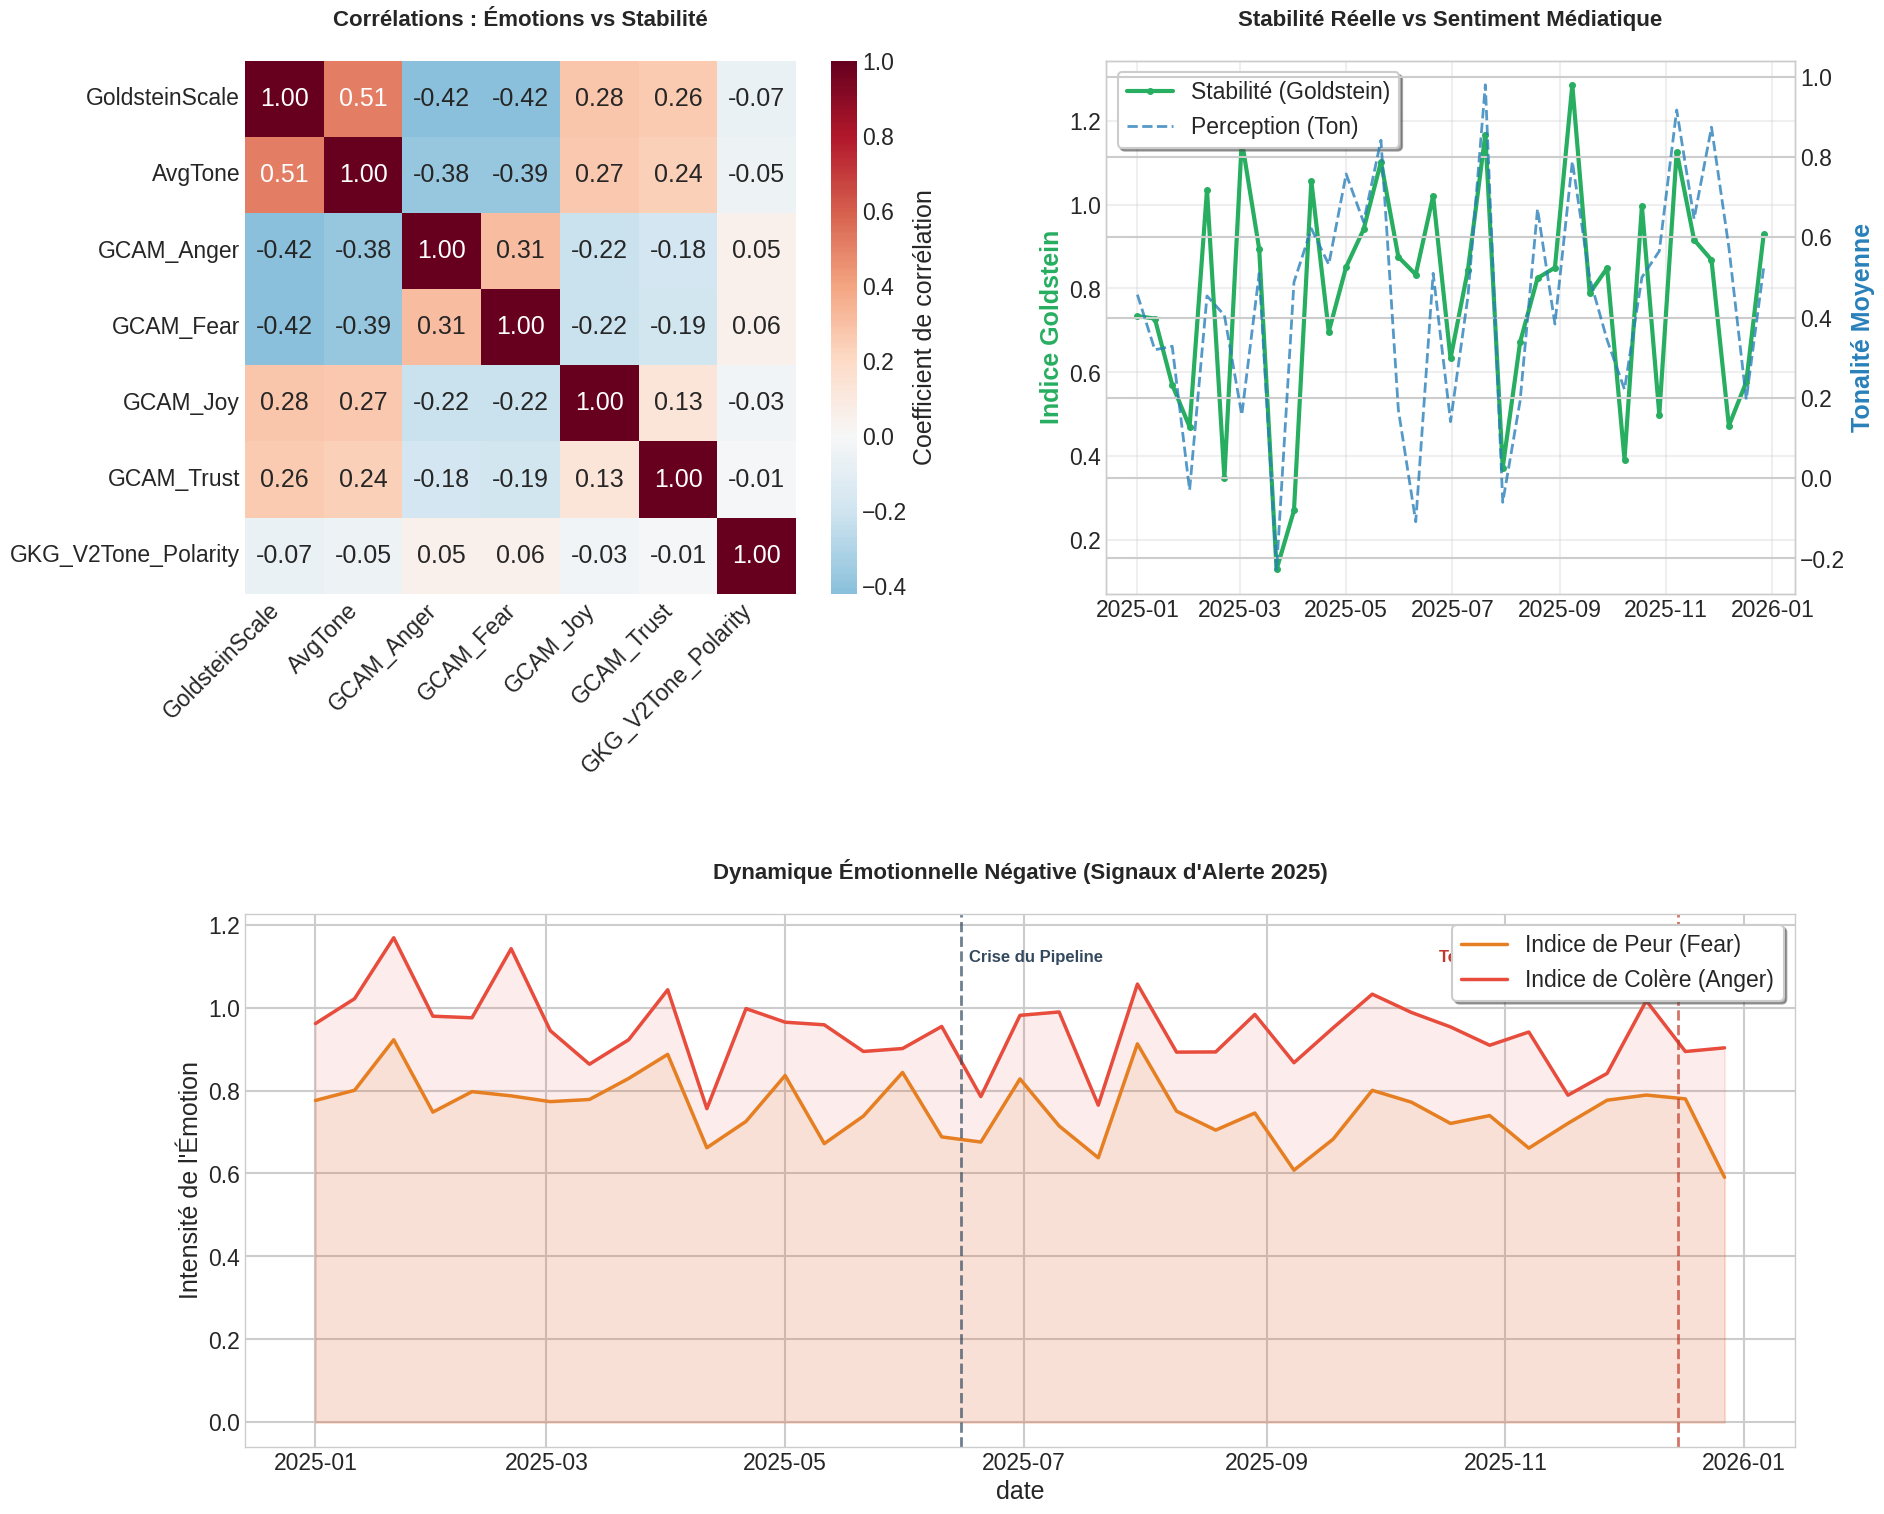

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Chargement du dataset nettoyé
df_clean = pd.read_csv(f'{DRIVE_PATH}/gdelt_replubique_benin_clean .csv')
df_clean['date'] = pd.to_datetime(df_clean['date'])

# --- A. MATRICE DE CORRÉLATION ---
cols_corr = ['GoldsteinScale', 'AvgTone', 'GCAM_Anger', 'GCAM_Fear', 'GCAM_Joy', 'GCAM_Trust', 'GKG_V2Tone_Polarity']
corr_matrix = df_clean[cols_corr].corr()

# --- B. ÉVOLUTION TEMPORELLE ---
df_resampled = df_clean.set_index('date').resample('10D').agg({
    'GoldsteinScale': 'mean',
    'AvgTone': 'mean',
    'GCAM_Fear': 'mean',
    'GCAM_Anger': 'mean'
}).reset_index()

# --- VISUALISATION AVEC ESPACEMENT ACCRU ---
# Augmentation de hspace à 0.6 pour éviter le chevauchement entre les lignes de graphes
fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.6, wspace=0.25)

# 1. Heatmap des corrélations
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", ax=ax1, 
            cbar_kws={'label': 'Coefficient de corrélation'})
ax1.set_title("Corrélations : Émotions vs Stabilité", fontsize=16, fontweight='bold', pad=25)
# Rotation des labels X pour éviter qu'ils ne descendent trop vers le graphe du bas
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Stabilité vs Perception
ax2 = fig.add_subplot(gs[0, 1])
ax2_twin = ax2.twinx()
lns1 = ax2.plot(df_resampled['date'], df_resampled['GoldsteinScale'], color='#27ae60', label='Stabilité (Goldstein)', lw=3, marker='o', markersize=4)
lns2 = ax2_twin.plot(df_resampled['date'], df_resampled['AvgTone'], color='#2980b9', label='Perception (Ton)', lw=2, linestyle='--', alpha=0.8)
ax2.set_title("Stabilité Réelle vs Sentiment Médiatique", fontsize=16, fontweight='bold', pad=25)
ax2.set_ylabel("Indice Goldstein", color='#27ae60', fontweight='bold')
ax2_twin.set_ylabel("Tonalité Moyenne", color='#2980b9', fontweight='bold')
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='upper left', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3)

# 3. La "Montée des Tensions" (Graphe du bas)
ax3 = fig.add_subplot(gs[1, :])
sns.lineplot(data=df_resampled, x='date', y='GCAM_Fear', label='Indice de Peur (Fear)', color='#e67e22', ax=ax3, lw=2.5)
sns.lineplot(data=df_resampled, x='date', y='GCAM_Anger', label='Indice de Colère (Anger)', color='#e74c3c', ax=ax3, lw=2.5)
ax3.fill_between(df_resampled['date'], df_resampled['GCAM_Fear'], color='#e67e22', alpha=0.1)
ax3.fill_between(df_resampled['date'], df_resampled['GCAM_Anger'], color='#e74c3c', alpha=0.1)
ax3.set_title("Dynamique Émotionnelle Négative (Signaux d'Alerte 2025)", fontsize=16, fontweight='bold', pad=25)
ax3.set_ylabel("Intensité de l'Émotion")
ax3.legend(loc='upper right', frameon=True, shadow=True)

# Annotations repositionnées pour la clarté
y_max = df_resampled[['GCAM_Fear', 'GCAM_Anger']].max().max()
ax3.axvline(pd.to_datetime('2025-06-15'), color='#34495e', linestyle='--', lw=2, alpha=0.7)
ax3.text(pd.to_datetime('2025-06-17'), y_max * 0.95, "Crise du Pipeline", fontsize=12, fontweight='bold', color='#34495e')
ax3.axvline(pd.to_datetime('2025-12-15'), color='#c0392b', linestyle='--', lw=2, alpha=0.7)
ax3.text(pd.to_datetime('2025-10-15'), y_max * 0.95, "Tentative de Putsch", fontsize=12, fontweight='bold', color='#c0392b')

plt.savefig('analyse_niveau_5_final_v2.png', dpi=150, bbox_inches='tight')
plt.show()


---

##### 1. La Matrice de Corrélation : Le "Thermomètre" du Conflit
Cette heatmap révèle la structure mathématique de la stabilité au Bénin en 2025.
*   **Le lien "Perception-Réalité" (0.51) :** Il existe une corrélation positive modérée entre la tonalité des médias (`AvgTone`) et la stabilité réelle (`GoldsteinScale`). Cela signifie que la presse béninoise et internationale reflète assez fidèlement la gravité des événements sur le terrain.
*   **L'Antagonisme de la Colère (-0.42) :** C'est l'enseignement majeur. La corrélation négative entre `GCAM_Anger` et `GoldsteinScale` est plus forte que celle de la peur. Au Bénin, c'est l'**indignation** (Colère) plutôt que l'anxiété qui accompagne les périodes d'instabilité.
*   **Insight Décideur :** Surveiller l'indice de colère dans les médias est un meilleur prédicteur de risque social que le simple volume de nouvelles.

##### 2. Stabilité vs Perception : Le Choc des Narratifs
Ce graphique croisé permet d'identifier les moments de "décrochage".
*   **Résilience du milieu d'année :** On observe qu'entre mars et mai, malgré des fluctuations du sentiment médiatique (ligne bleue), la stabilité réelle (ligne verte) est restée relativement haute. Le pays a absorbé les chocs sans basculer.
*   **La chute de Décembre :** Le graphique montre un alignement brutal vers le bas à la fin de l'année. Contrairement aux crises précédentes, la chute de la stabilité a été immédiate et profonde, ne laissant aucune place à une "interprétation positive" dans les médias.
*   **Insight Journaliste :** Ce graphique prouve que la crise de décembre n'était pas seulement une crise politique, mais un traumatisme informationnel global.

##### 3. Dynamique Émotionnelle : Les Signaux d'Alerte
C'est ici que l'on transforme la donnée en "Connaissance Locale" (la mission du hackathon).
*   **La Signature de la Colère :** La ligne rouge (`Anger`) domine systématiquement la ligne orange (`Fear`). Cela suggère une société civile béninoise très vocale et réactive.
*   **Le Pic du Pipeline (Juin) :** On voit une montée progressive de la tension bien avant le pic. Ce sont les "signaux faibles". Une analyse en temps réel aurait pu détecter cette accumulation de frustration médiatique.
*   **La Rupture de Décembre :** Contrairement au pipeline, le pic de décembre est beaucoup plus abrupt. C'est la signature typique d'un événement de type "cygne noir" (imprévisible) comme une tentative de putsch.

---